# Notebook to Analyze Tuning Curves + Fit to Cosine/Von Mises Functions 
Note: If plot font looks strange, re-run code block, some sections marked "(old)" are from last year

In [2]:
# import and load modules
%reload_ext autoreload
%autoreload 2
import pprint
import operator
from datetime import date
import numpy as np; import pandas as pd; import math as math; import copy; import statistics
from scipy.ndimage import gaussian_filter as gaussian_filter; import scipy.stats as stats
import statsmodels.api as sm; lowess = sm.nonparametric.lowess; from skimage import transform
from scipy.optimize import curve_fit
from scipy.special import i0 

#from loess.loess_1d import loess_1d;
import seaborn as sns
from seaborn import violinplot
from seaborn import load_dataset
from seaborn import kdeplot

#mworks importsc
#from mworksbehavior import mwkfiles; from mworksbehavior.imaging import intrinsic as ii; import mworksbehavior as mwb; import mworksbehavior.mwk_io

import matplotlib as mpl; import matplotlib.pyplot as plt; import matplotlib.gridspec as gridspec; from matplotlib import cm; from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable #from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle; from matplotlib.patches import Rectangle

import os, sys; from glob import glob; from pathlib import Path; import pickle
import tifffile as tfl; from datetime import datetime

sys.path.append('C:/Users/Connor/Repositories/analysisConnor2025/src') 
import quietcell_select_fxns_all as qcsf
import compareQuiet as cQ

#local files and shorthand notations for assigning common functions to variable names
r_ = np.r_; a_ = np.asarray

# Functions

In [3]:
# Inputs: trial data, orientation placeholder, and average data (just for shape)
# Outputs: average tuning curves for cells in average data using sample w replacement
def sample_w_replacement(input_trial_data,orientations,desired_output_shape):

    # Create a variable that repeats the orientation as many times as there are trials
    # Repeating orientations to pair angles with bootstrapped data 
    ori_holder = []
    ori_temp = orientations.tolist()
    
    for i in range(input_trial_data.shape[2]): # assumes dim 2 is the trials dim
        ori_holder.append(ori_temp)
    
    ori_holder = np.array(ori_holder).flatten()
    
    # Creating code to resample from the data to length of 180
    resampled_dfof = np.empty_like(ori_holder).astype(float)
    resampled_angles = np.empty_like(ori_holder)
    averages = np.empty(desired_output_shape)
    
    # Generate a random integer in the range of the samples (180), need to loop across cells 
    for i in range(desired_output_shape[0]): 
    
        # Now sample across 180, 180 times (rand so automatically with replacement)
        # and then calculate averages for each orientation to pass into the curve-fitting
        for ind in range(ori_holder.shape[0]):
            
            rand_ind = np.random.randint(ori_holder.shape[0])
    
            # Unravel data to have length 180 (30 trials with 6 orientations), this is dfof data
            # then pair y-value with appropriate x 
            ravel_data = input_trial_data[i].ravel()
            resampled_dfof[ind] = ravel_data[rand_ind]
            resampled_angles[ind] = ori_holder[rand_ind]
    
        # Now pair y-values based on x for average
        ori_bool = [resampled_angles == ori for ori in orientations]
        binned_y = [resampled_dfof[ori] for ori in ori_bool]
            
        # Checking the number of values for each orientation, DO LATER 
    
        # Averaging each y-value for fitting and store
        averages[i] = [np.mean(vals) for vals in binned_y]

    return averages 

In [4]:
# Make asterisks
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

In [5]:
def circular_variance(angles_rad, responses): # Genereated using AI 
    """
    Compute the circular variance of a neural tuning curve.

    Parameters:
    - angles_rad: array-like, angles in radians
    - responses: array-like, corresponding firing rates or weights

    Returns:
    - circular variance (float, between 0 and 1)
    """
    # Convert to complex exponentials
    vector_sum = np.sum(responses * np.exp(1j * angles_rad))
    R = np.abs(vector_sum) / np.sum(responses)  # Mean resultant length % if responses are all negative
    circ_var = 1 - R
    return circ_var

# Set-up & Basic Tuning Analysis

## Loading in Trial Data

In [8]:
base_dir = os.path.expanduser('~\\data-local\\250405')
data_dir = base_dir + '\\numpys'

# Create a directory for the current day to store current figures 
date_str = '\\' + str(date.today())
fig_dir = base_dir + '\\figures' + date_str

# If directory doesn't exist, create one else do nothing  
if os.path.isdir(fig_dir) is False:
    Path(fig_dir).mkdir(parents=True, exist_ok=False)
    print('dir created')
else:
    print('dir exists')

pre_data = []
post_data = []
pre_ctrl = []
post_ctrl = []

animals = os.listdir(data_dir)
for animal in animals: 
    animal_dir = data_dir+'\\'+animal
    inds = np.load(animal_dir+'\\stim_iC_manip.npy')
    inds_ctrl = np.load(animal_dir+'\\ctrl_iC.npy')
    # Store arrays as elements in a list, filtered by appropriate indicies
    pre_data.append(np.load(animal_dir+'\\dfof_cellTrials_pre.npy')[inds,:])
    pre_ctrl.append(np.load(animal_dir+'\\dfof_cellTrials_pre.npy')[inds_ctrl,:])
    post_data.append(np.load(animal_dir+'\\dfof_cellTrials_post.npy')[inds,:])
    post_ctrl.append(np.load(animal_dir+'\\dfof_cellTrials_post.npy')[inds_ctrl,:])

# Stack arrays in list to create one array of all animal's cells 
pre_data = np.vstack(pre_data)
pre_ctrl = np.vstack(pre_ctrl)
post_data = np.vstack(post_data)
post_ctrl = np.vstack(post_ctrl)

# Constants
orientations = np.array([0, 30, 60, 90, 120, 150])
num_cells = pre_data.shape[0]

dir exists


## Calculating Mean and Error

In [6]:
# Trained cells mean
visResp_behavStim_pre = pre_data.mean(axis=2)
visResp_behavStim_post = post_data.mean(axis=2)
# Trained cells error 
pre_err = stats.sem(pre_data,axis=2) 
post_err = stats.sem(post_data,axis=2)
# Control cells mean 
visResp_notStim_pre = pre_ctrl.mean(axis=2)
visResp_notStim_post = post_ctrl.mean(axis=2)
# A filter for lower quality control data (i.e. filtering all cells identified by suite2p), 
#can make 7% could also be any orientation in pre or post
i_notStimResponsive = np.where(visResp_notStim_pre[:,3] > 2.5)[0] 
stat, p_post = stats.mannwhitneyu(visResp_behavStim_post, visResp_notStim_post)

# Calculating the tuning change for control & trained cells 
dfoF_V_change_ctrl = visResp_notStim_post[i_notStimResponsive,:] - visResp_notStim_pre[i_notStimResponsive,:]
dfoF_V_change_bhStim = visResp_behavStim_post - visResp_behavStim_pre
# Calculating change then sem
sem_set_up = post_data - pre_data 
sem_change = stats.sem(sem_set_up,axis=2)

## Individual Cell Tuning Plots
Creates pre-post tuning plots and change tuning plots

In [32]:
# Appending the 0 deg column to the end for the +90 condition 
add_col = np.expand_dims(visResp_behavStim_pre[:,0],axis=1)
bhStim_pre = np.append(visResp_behavStim_pre,add_col,axis=1)
plot_pre_err = np.concatenate((pre_err, pre_err[:,:1]),axis=1)


add_col = np.expand_dims(visResp_behavStim_post[:,0],axis=1)
bhStim_post = np.append(visResp_behavStim_post,add_col,axis=1)
plot_post_err = np.concatenate((post_err, post_err[:,:1]),axis=1)

# same for change sem 
sem_bhStim = np.concatenate((sem_change, sem_change[:,:1]),axis=1)

# Checking if the appropriate column was appended:
print(f"Do the first and last columns of the visual response match?: {all((bhStim_post[:,0] == bhStim_post[:,-1]))}")

Do the first and last columns of the visual response match?: True


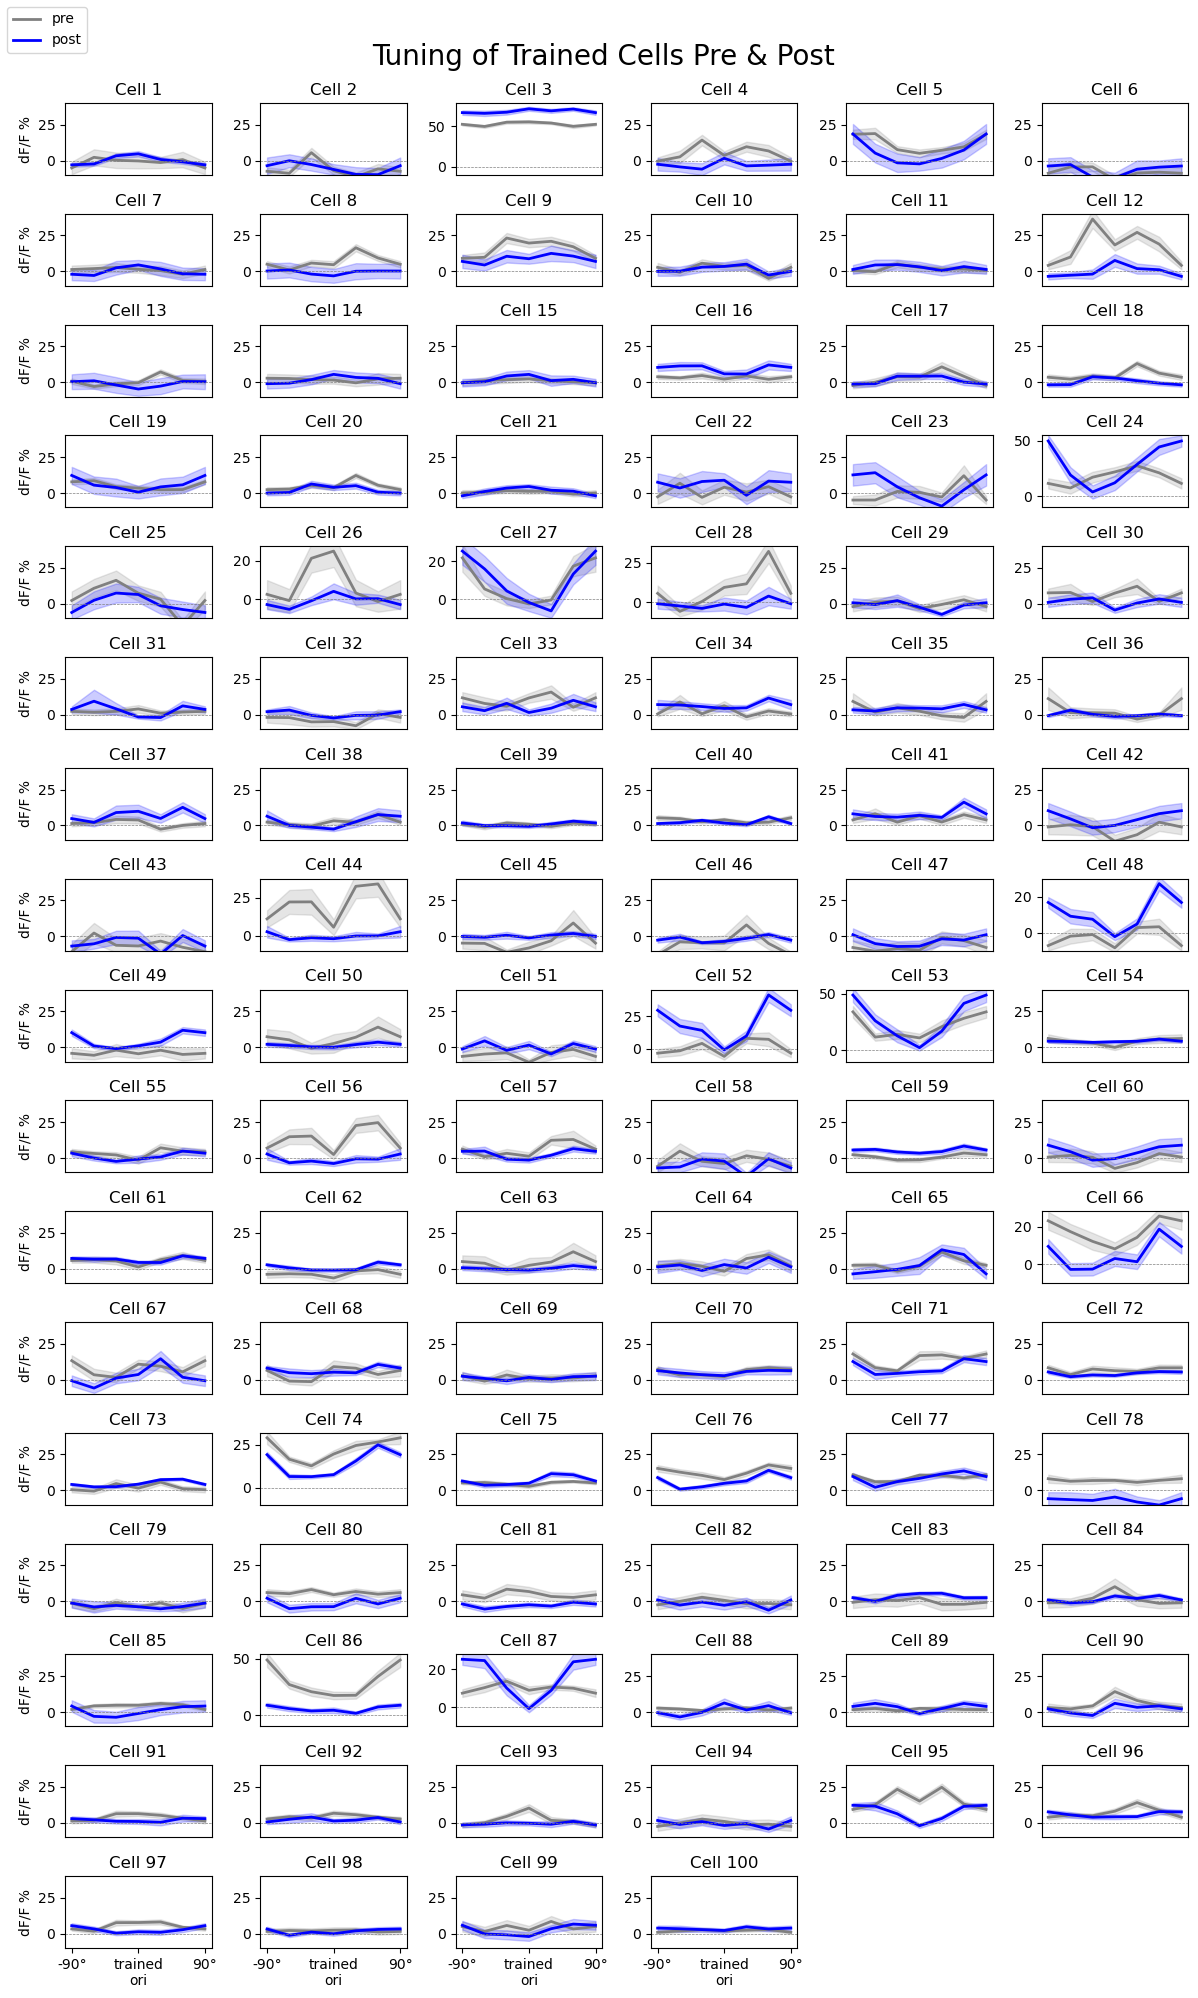

In [64]:
# Plotting all the pre- and post-tuning of each cell

# Set the dimensions of the subplot grid
cols = 6
rows = int(np.ceil(len(dfoF_V_change_bhStim)/cols))

# Create a figure and a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 20))
xs = [0,np.pi*0.167,np.pi*0.333,np.pi*0.5,np.pi*0.667,np.pi*0.833,np.pi]

pre_color = 'gray'
post_color = 'blue'


axes = axes.flatten()

# Iterate through each subplot
for i in range(dfoF_V_change_bhStim.shape[0]):
        
    ax = axes[i]
    ax.plot(xs,bhStim_pre[i,:],lw=2,color=pre_color,label='pre')
    ax.fill_between(xs,bhStim_pre[i,:]+plot_pre_err[i,:],bhStim_pre[i,:]-plot_pre_err[i,:],color= pre_color,alpha=0.2)
    
    ax.plot(xs,bhStim_post[i,:],lw=2,color=post_color,label='post')
    ax.fill_between(xs,bhStim_post[i,:]+plot_post_err[i,:],bhStim_post[i,:]-plot_post_err[i,:],color= post_color,alpha=0.2)

    ax.axhline(0, color='gray',lw=0.5,linestyle='--')

    
    # # To account for a cell with higher responses & to add label to first plot  
    # if i == 21:
    #     ax.set_ylim([-100, 100])
    # elif i == 0:
    #     ax.set_ylabel("dF/F %")
    # else:
    #     ax.set_ylim([-10, 40])   
        
    ax.set_title(f'Cell {i + 1}', fontsize=12)
    
    
    # Code to set the ylims based on values with a minimum of 25% 
    if any(bhStim_pre[i,:] > 25) or any(bhStim_post[i,:] > 25):
        y_max = np.max(np.concatenate((bhStim_pre[i,:],bhStim_post[i,:])))*1.1 # Making max ylim 1.1 
        ax.set_ylim([-10,y_max])
        
    else: 
        ax.set_ylim([-10, 40])   
        
    if i == 0:
        fig.legend(loc='upper left')
        
    # Setting only the first column to have y labels 
    if np.remainder(i,cols) == 0:
        ax.set_ylabel("dF/F %")
    
    # Setting only the last row to have x labels 
    if (rows*cols) - i - 1< cols:
        ax.set_xticks(
            ticks=[0, np.pi*0.5, np.pi],
            labels=["-90\u00b0", "trained\nori", "90\u00b0"])  
    else: 
        ax.set_xticks(
            ticks=[],
            labels=[])

# Removing axes greater than the number of cells 
for ind in range(rows*cols - dfoF_V_change_bhStim.shape[0]):
    ax = axes[dfoF_V_change_bhStim.shape[0] + ind]
    ax.axis('off') 
        
plt.tight_layout()
plt.rcParams.update({'font.size': 12}) 
fig.suptitle("Tuning of Trained Cells Pre & Post", fontsize = 20)
fig.subplots_adjust(top=0.95)

# Save figure
plt.savefig(fig_dir + '\\tuning_curves.png')

plt.show()

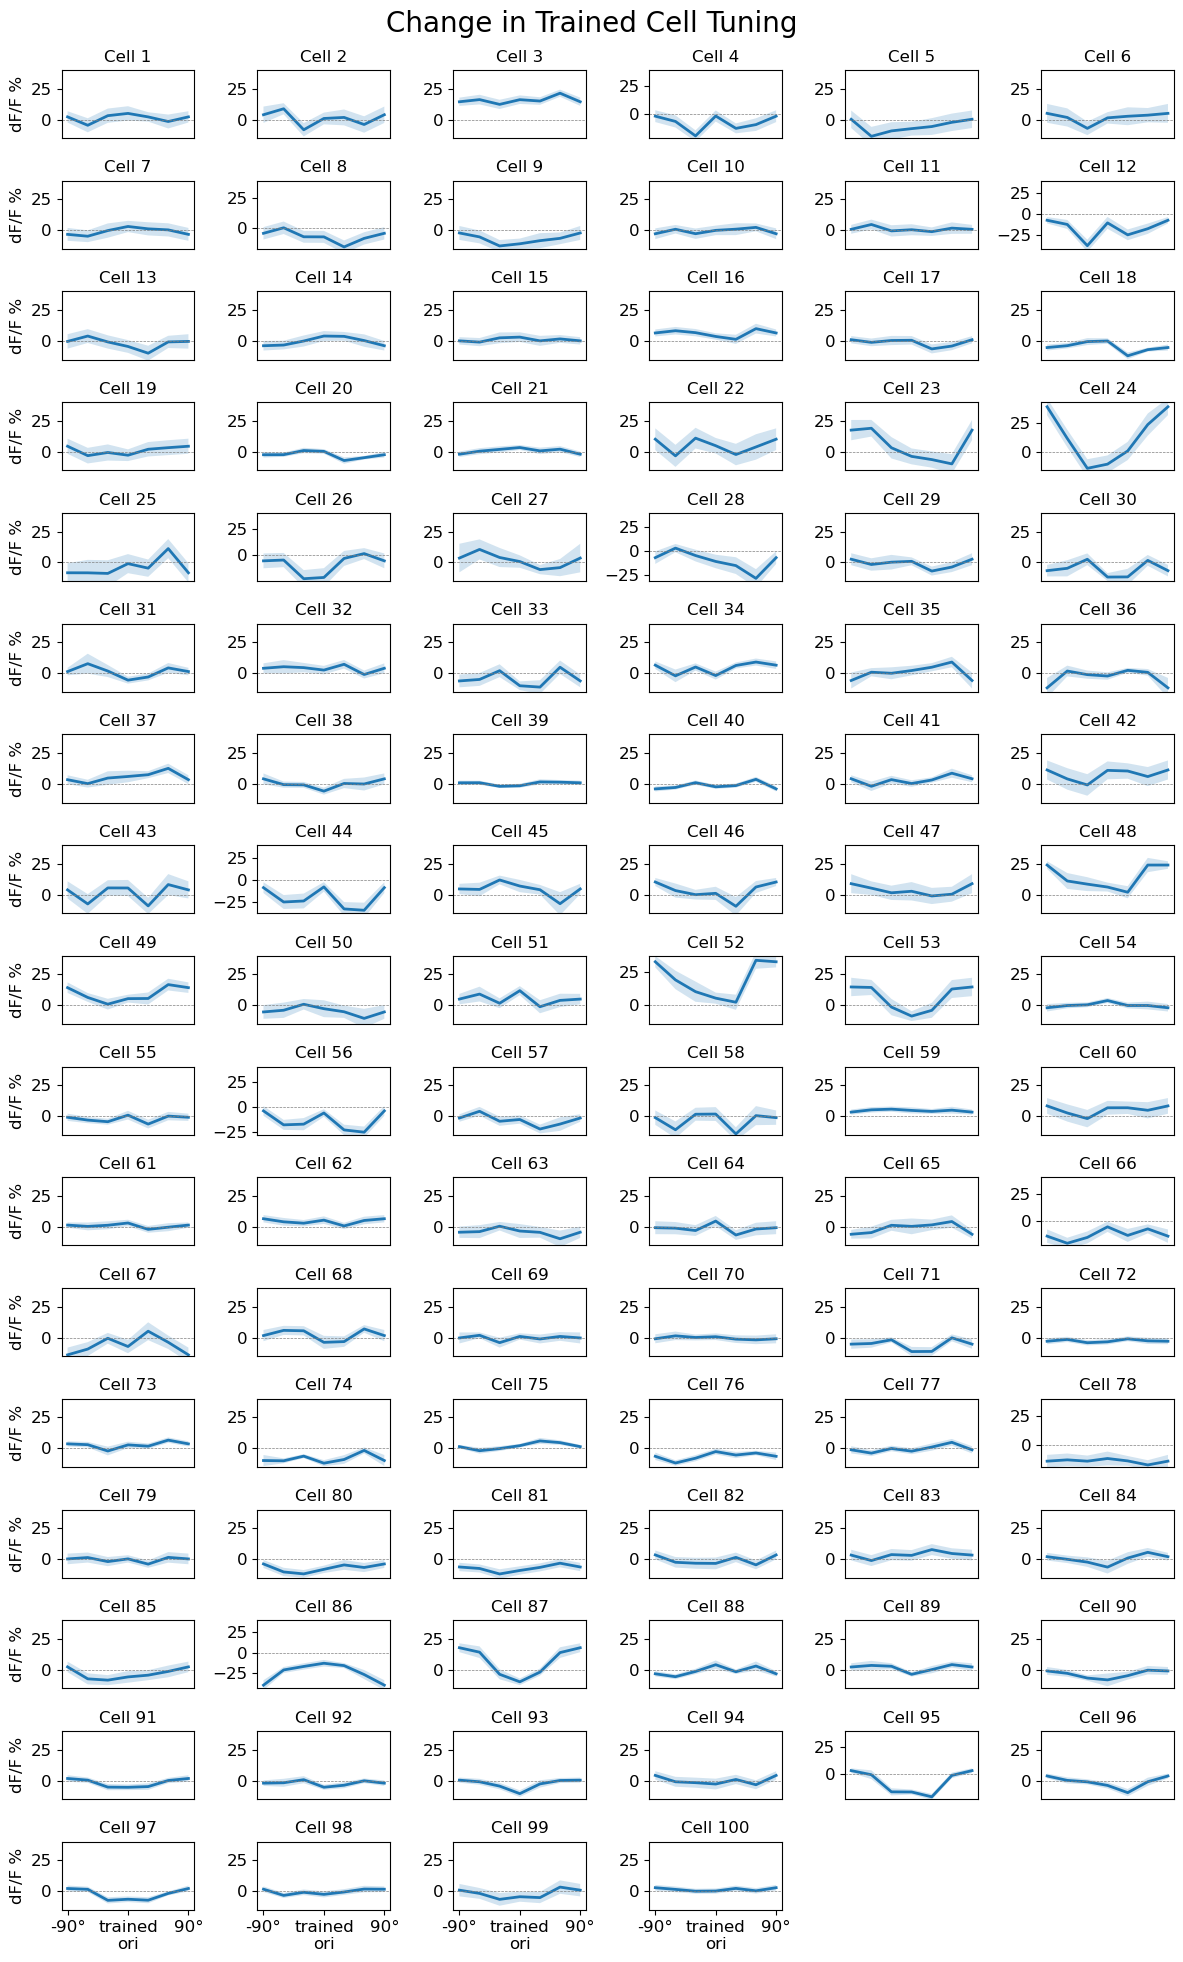

In [65]:
# Plotting the change in tuning for each cell 

# Create a figure and a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 20))
axes = axes.flatten() # to make iterable

xs = [0,np.pi*0.167,np.pi*0.333,np.pi*0.5,np.pi*0.667,np.pi*0.833,np.pi]

add_col = np.expand_dims(dfoF_V_change_bhStim[:,0],axis=1)
bhStim_total = np.append(dfoF_V_change_bhStim,add_col,axis=1)

# Iterate through each subplot
for i in range(dfoF_V_change_bhStim.shape[0]):
    ax = axes[i]
    ax.plot(xs,bhStim_total[i,:],lw=2)
    ax.fill_between(xs,bhStim_total[i,:]+sem_bhStim[i,:],bhStim_total[i,:]-sem_bhStim[i,:],alpha=0.2)
    ax.axhline(0, color='gray',lw=0.5,linestyle='--')
    #ax.set_ylim([-40, 40])
    ax.set_title(f'Cell {i + 1}', fontsize=12)
    ax.set_xticks(
        ticks=[0, np.pi*0.5, np.pi],
        labels=["-90\u00b0", "trained\nori", "90\u00b0"])
    
    if i == 0:
        ax.set_ylabel('\u0394d F/F%')
        
        
 # Code to set the ylims based on values with a minimum of 25% 
    y_max = 40 
    y_min = -15
    if any(bhStim_total[i,:] > 25):
        y_max = np.max(bhStim_total[i,:])*1.1 # Making max ylim 1.1 
        
    if any(bhStim_total[i,:] < -15):
        y_min = np.min(bhStim_total[i,:])*1.1 # Making max ylim 1.1 

    ax.set_ylim([y_min,y_max])
 
        
    # Setting only the first column to have y labels 
    if np.remainder(i,cols) == 0:
        ax.set_ylabel("dF/F %")
    
    # Setting only the last row to have x labels 
    if (rows*cols) - i - 1< cols:
        ax.set_xticks(
            ticks=[0, np.pi*0.5, np.pi],
            labels=["-90\u00b0", "trained\nori", "90\u00b0"])  
    else: 
        ax.set_xticks(
            ticks=[],
            labels=[])

# Removing axes greater than the number of cells 
for ind in range(rows*cols - dfoF_V_change_bhStim.shape[0]):
    ax = axes[dfoF_V_change_bhStim.shape[0] + ind]
    ax.axis('off') 

plt.tight_layout()
plt.rcParams.update({'font.size': 10}) 
fig.suptitle("Change in Trained Cell Tuning", fontsize = 20)
fig.subplots_adjust(top=0.95)

# Save figure
plt.savefig(fig_dir + '\\tuning_change_curves.png')

plt.show()

## Identifying quiet cells in the data 

In [8]:
# Cell that calculates quiet cells in trained and control populations 
quiet_cell_threshold = 10 # Percent
group_names = ["Trained", "Control"]
qc_store_pre = []
qc_store_post = []
stay_qc_store = []
lost_qc_store = []

ctrl_vis_pre = visResp_notStim_pre[i_notStimResponsive,:]
ctrl_vis_post = visResp_notStim_post[i_notStimResponsive,:]

# Trained and control data for pre and post 
pre = [visResp_behavStim_pre, 
            ctrl_vis_pre]

post = [visResp_behavStim_post,
             ctrl_vis_post]

trained = 0 
control = 1 

# Looping through trained and control data trained is 0 control is 1 
for group in range(2): 
    
    pre_loop = pre[group] 
    post_loop = post[group] 
    
    # Calculating the number of quiet cells in our data
    # loop through cells (row) and find which rows have all entries less that threshold (some dF/F percentage) 
    pre_quiet_cells = [np.all(np.abs(pre_loop[row,:]) < quiet_cell_threshold) for row in range(pre_loop.shape[0])] 
    post_quiet_cells = [np.all(np.abs(post_loop[row,:]) < quiet_cell_threshold) for row in range(post_loop.shape[0])]
    stay_quiet_cells = np.logical_and(pre_quiet_cells,post_quiet_cells)
    # Condition for is initially quiet and not a stay quiet cell, meaning it gains a response
    lost_quiet_cells = np.logical_and(pre_quiet_cells,~stay_quiet_cells)
    
    # Print Block for Info
    print("%s Cells" %group_names[group])
    print("Number of starting quiet cells: %i" % len([i for i, x in enumerate(pre_quiet_cells) if x])) # If x (entry) is True, store index i then count list
    print("Number of ending quiet cells: %i" % len([i for i, x in enumerate(post_quiet_cells) if x]))
    print("Cells that remained quiet: %i" % len([i for i, x in enumerate(stay_quiet_cells) if x]))
    print("Cells that gained tuning: %i" % len([i for i, x in enumerate(lost_quiet_cells) if x]))
    percent_stay_quiet = len([i for i, x in enumerate(stay_quiet_cells) if x])/pre_loop.shape[0]*100
    percent_lost_quiet = len([i for i, x in enumerate(lost_quiet_cells) if x])/pre_loop.shape[0]*100
    print("Percent of cells that remained quiet: %i%%" % int(percent_stay_quiet))
    print("Percent of cells that gained a tuning: %i%%\n" % int(percent_lost_quiet))
    
    # Append arrays for later use, remember index [0] is trained cells index [1] is post
    qc_store_pre.append(pre_quiet_cells)
    qc_store_post.append(post_quiet_cells)
    stay_qc_store.append(stay_quiet_cells)
    lost_qc_store.append(lost_quiet_cells)
    
# Pulling out stay quiet cells for data analysis in case
trained_stay_quiet_cells = stay_qc_store[trained]
ctrl_stay_quiet_cells = stay_qc_store[control] 

Trained Cells
Number of starting quiet cells: 54
Number of ending quiet cells: 69
Cells that remained quiet: 42
Cells that gained tuning: 12
Percent of cells that remained quiet: 42%
Percent of cells that gained a tuning: 12%

Control Cells
Number of starting quiet cells: 525
Number of ending quiet cells: 557
Cells that remained quiet: 450
Cells that gained tuning: 75
Percent of cells that remained quiet: 59%
Percent of cells that gained a tuning: 9%



In [34]:
# Removing quiet cells from tuning curve analysis - TRAINED CELLS ONLY see 0 index, 1 is control cells
# This will create variables you can use to remove quiet cells from tuning curve fits, currently all cells are included
qc_inds_pre = np.array(qc_store_pre[0]) # changing to numpy to reverse later
qc_inds_post = np.array(qc_store_post[0])
no_qc_vis_pre = visResp_behavStim_pre[~qc_inds_pre]
no_qc_vis_post = visResp_behavStim_pre[~qc_inds_post]

# Fitting Curves to Tuning Data
Two methods, von mises and cosine. Steps for each method are:
1. Initialization of required variables
2. Fitting to mean tuning curves
3. Assesment of fit quality
4. Plot fit for a visual assessment
5. Bootstrapping, essentially runs steps 1 and 2 but does so on data sampled w/ replacement from our data
6. Calculate and visualize confidence intervals for bootstrapped parameters

Note: cosine code is most robust

## Von-Mises Fit

### Standard Von Mises

In [22]:
# Allocating variables for tuning curve fitting
points_in_fit = 300
# y-values of fit 
fit_response = np.ndarray((2,num_cells,points_in_fit)) # first dimension is 2 to store pre and post fits
# kappa is a width parameter of the von mises distribution
A_fit = np.ndarray((2,num_cells))
kappa_fit = np.ndarray((2,num_cells))
mu_fit = np.ndarray((2,num_cells))
B_fit = np.ndarray((2,num_cells))

# x-value for the fit 
#theta_fit = np.linspace(0, np.pi*5/6, 300)  # 0° to 180° in radians
theta_fit = np.linspace(0, np.pi*5/6, 300)  # 0° to 180° in radians
# Alt. width parameter 
fwhm_vm = np.ndarray((2,num_cells))

In [23]:
# Looping through pre and post to get measures for both
#for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
    # Iterate through each cell
    for i_cell in range(data.shape[0]):

        # Step 1: Input your data
        responses = data[i_cell,:]

        # Normalize the data 
        responses = responses
        
        # Convert to radians
        orientations_rad = np.deg2rad(orientations)

        # Step 2: Define von Mises tuning function
        def von_mises_tuning(theta, A, kappa, mu, B):
            return A*np.exp(kappa * np.cos(theta - mu)) / (2 * np.pi * i0(kappa)) + B 

        # Step 3: Initial parameter guess: [A, kappa, mu, B]
        A = responses.max() - responses.min()
        kappa = 1
        mu = orientations_rad[np.argmax(responses)]
        B = np.min(responses)
        initial_guess = [A, kappa, mu, B]

        try:
            # Step 4: Curve fitting
            params, _ = curve_fit(von_mises_tuning, orientations_rad, responses, p0=initial_guess)
            A_fit, kappa_fit[i_data,i_cell], mu_fit[i_data,i_cell], B_fit[i_data,i_cell] = params

            # Step 5: Plot result
            fit_response[i_data,i_cell,:] = von_mises_tuning(theta_fit, *params)

             # Calculate the FWHM for each cell
            peak_val = fit_response[i_data,i_cell,:].max()
            peak_ind = np.abs(fit_response[i_data,i_cell,:] - peak_val).argmin()
            half_max = peak_val / 2

            # Calculating indices where x-values of data-points would be 
            half_ind = np.abs(fit_response[i_data,i_cell,:] - half_max).argmin()
            
            # Assuming (for now) fits are symmetric so can double HWHM
            fwhm_vm[i_data,i_cell] = (theta_fit[peak_ind] - theta_fit[half_ind])*2

        except RuntimeError:
            fit_response[i_data,i_cell,:] = [np.nan]*points_in_fit  
            fwhm_vm[i_data,i_cell] = np.nan

C:\Users\Connor\AppData\Local\Temp\ipykernel_30052\1221167082.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(von_mises_tuning, orientations_rad, responses, p0=initial_guess)


#### Checking fit quality 

In [24]:
# Converting to degrees for readability
fwhm_vm = np.abs(np.rad2deg(fwhm_vm)) 

# Calculating indices where x-values of data-points would be 
indices = np.array([np.abs(np.rad2deg(theta_fit) - ori).argmin() for ori in orientations])

# Variance Accounted For (VAF), calculate average VAF across iterations for each cell
#vaf = [(1 - np.var(no_qc_vis_pre[cell,:] - fit_response[pre,cell,indices])/np.var(no_qc_vis_pre[cell,:]))*100 for cell in range(no_qc_vis_pre.shape[0])]

# # Normalized visual response 
# pre = 0
# norm_data = np.ndarray(visResp_behavStim_pre.shape)
# for cell in range(num_cells):
#     norm_data[cell,:] = visResp_behavStim_pre[cell,:]/np.max(np.abs(visResp_behavStim_pre[cell,:])) 


# Calculating VAF for each iteration then averaging
vaf = [(1 - np.var(visResp_behavStim_pre[i_cell,:] - fit_response[0,i_cell,indices])/np.var(visResp_behavStim_pre[i_cell,:]))*100 for i_cell in range(num_cells)]

# Calculating goodness of fit as described by Swindale et al. 1998:https://link.springer.com/article/10.1007/s004220050411
# Step one 
y = np.ndarray((2,num_cells,orientations.shape[0]))
rms = np.ndarray((2,num_cells))
for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
    for i_cell in range(num_cells):
        R = visResp_behavStim_pre[i_cell,:]
        f = fit_response[i_data,i_cell,indices]
        A = fit_response[i_data,i_cell,:].max()
        y[i_data,i_cell,:] = 100*(R-f)/A
        y_sq = [x**2 for x in y[i_data,i_cell,:]]
        rms[i_data,i_cell] = np.sqrt(np.sum(y_sq)/len(y_sq))

# Print metrics of fitting
num_cells_fit = len(np.where(~np.isnan(fwhm_vm[0,:]))[0])
p_cells_fit = num_cells_fit/len(visResp_behavStim_pre)*100
count_vaf_threshold = np.where(np.array(vaf)>80)[0].shape[0]
avg_rms = np.nanmean(rms[0,:])

print("Cells fit succesfully: %i" %num_cells_fit)
print("Percent of cells fit: %i%%" %p_cells_fit)
print("Average variance accounted for: %.2f%%" %np.nanmean(vaf)) 
print("Cells above 80%% vaf: %i" %count_vaf_threshold)
print("Average normalized RMS value: %.2f" %avg_rms)


Cells fit succesfully: 77
Percent of cells fit: 77%
Average variance accounted for: 66.53%
Cells above 80% vaf: 31
Average normalized RMS value: 20.08


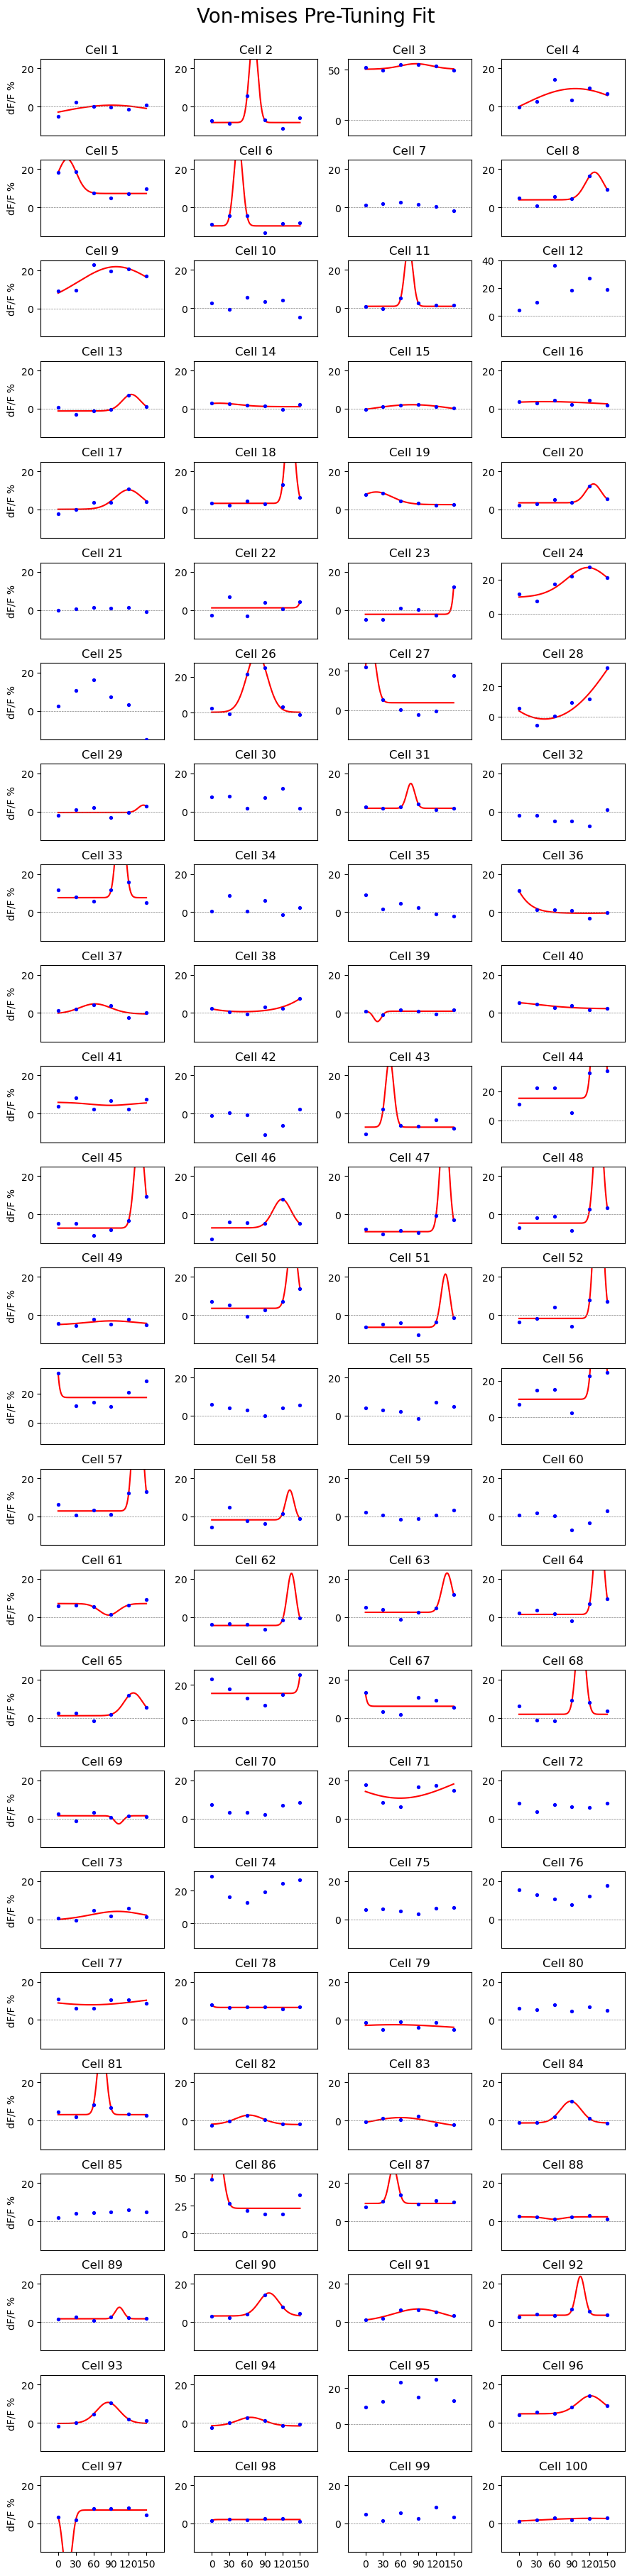

In [8]:
# Plotting the tuning fit for each cell
from scipy.optimize import curve_fit

# Set the dimensions of the subplot grid
cols = 4
rows = int(np.ceil(num_cells/cols))

# Create a figure and a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(9, 37))
axes = axes.flatten() # to make iterable

# Step 1: Input your data
orientations_rad = np.deg2rad(orientations)

x_labels = [str(i) for i in orientations]

# Iterate through each subplot
for i in range(num_cells):

    responses = visResp_behavStim_pre[i,:]
    
    ax = axes[i]
    ax.plot(theta_fit, fit_response[0,i,:], 'r-', label="Fit") # 0 ind is 1 is post
    ax.scatter(orientations_rad, responses, color='b', zorder=5, s=8, label="ΔF/F Data")
    # ax.errorbar(orientations_rad, responses/np.max(np.abs(responses)), yerr=no_qc_pre_err[i,:]/np.max(no_qc_pre_err[i,:]), linestyle="")
    ax.axhline(0, color='gray',lw=0.5,linestyle='--')
    ax.set_xlim([-np.pi/6, np.pi])
    ax.set_title(f'Cell {i + 1}', fontsize=12)
    # ax.text(orientations_rad[3],40,"k=%.2f" %kappa_fit[0,i])
    # ax.text(orientations_rad[3],32,"fwhm=%.2f" %fwhm_vm[0,i])

    # ax.set_xticks(
    #     ticks=[0, np.pi*0.5, np.pi],
    #     labels=["-90\u00b0", "trained\nori", "90\u00b0"])
    
    if i == 0:
        ax.set_ylabel('\u0394dF/F%')
        
    # Code to set the ylims based on values with a minimum of 25% 
    if any(responses > 20):
        y_max = np.max(responses)*1.1 # Making max ylim 1.1 
        ax.set_ylim([-15,y_max])
        
    else: 
        ax.set_ylim([-15, 25])  
    
    # # Code to set the ylims based on values with a minimum of 25% 
    # if any(visResp_behavStim_pre[i,:] > 50):
    #     limit = visResp_behavStim_pre[i,:]*1.1 # Making max ylim 1.1 
    #     y_max_ind = np.argmax(abs(limit)) 
        
    #     if limit[y_max_ind] > 0: 
    #         ax.set_ylim([-50,limit[y_max_ind]])
    #     else:
    #         ax.set_ylim([limit[y_max_ind],50])
    # else: 
    #     ax.set_ylim([-30, 50])   
        
    # Setting only the first column to have y labels 
    if np.remainder(i,cols) == 0:
        ax.set_ylabel("dF/F %")
  
    if (rows*cols) - i - 1< cols:
        ax.set_xticks(
            ticks=orientations_rad,
            labels=x_labels)
            #labels=["-90\u00b0", "trained\nori", "90\u00b0"])  
    else: 
        ax.set_xticks(
            ticks=[],
            labels=[])

# Removing axes greater than the number of cells 
for ind in range(rows*cols - num_cells):
    ax = axes[num_cells + ind]
    ax.axis('off') 

plt.rcParams.update({'font.size': 10}) 
plt.tight_layout()
fig.suptitle("Von-mises Pre-Tuning Fit", fontsize = 20)
fig.subplots_adjust(top=0.96)

# Save figure
plt.savefig(fig_dir + '\\von-mises-fit.png')

plt.show()

### Bootstrapped Von-Mises

In [19]:
# Allocating variables for tuning curve fitting
# where "2", makes space for pre and post data 

# Constants
points_in_fit = 300
bootstrapping_n = 10

# y-values of fit 
fit_response = np.ndarray((bootstrapping_n,2,num_cells,points_in_fit)) # first dimension is 2 to store pre and post fits
# x-value for the fit 
theta_fit = np.linspace(0, np.pi*5/6, 300)  # 0° to 180° in radians

# kappa is a width parameter of the von mises distribution
kappa_fit = np.ndarray((bootstrapping_n,2,num_cells))
# preferred ori
mu_fit = np.ndarray((bootstrapping_n,2,num_cells))

# Alt. width parameter 
fwhm_vm = np.ndarray((bootstrapping_n,2,num_cells))
# quality of fit measure 
vaf = np.ndarray((bootstrapping_n,2,num_cells))


In [20]:
# Looping through pre and post to get measures for both
#for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
for i_iter in range(bootstrapping_n):

    # Calculate new resampled data each iteration 
    pre_averages = sample_w_replacement(pre_data,orientations,visResp_behavStim_pre.shape)
    post_averages = sample_w_replacement(post_data,orientations,visResp_behavStim_post.shape)
        
    for i_data, data in enumerate([pre_averages,post_averages]):
        # Iterate through each cell
        for i_cell in range(data.shape[0]):
    
            # Input your data
            responses = data[i_cell,:]
    
            # Normalizing the data, since amplitude is not a parameter in the function below
            responses = responses/np.max(np.abs(responses))
            
            # Convert to radians
            orientations_rad = np.deg2rad(orientations)
    
            # Define von Mises tuning function
            def von_mises_tuning(theta, kappa, mu, B):
                return np.exp(kappa * np.cos(theta - mu)) / (2 * np.pi * i0(kappa)) + B 
    
            # Initial parameter guess: [A, kappa, mu, B]
            #A = np.max(responses) - np.min(responses)
            kappa = 1
            mu = orientations_rad[np.argmax(responses)]
            B = np.min(responses)
            initial_guess = [kappa, mu, B]
    
            try:
                # Step 4: Curve fitting
                params, _ = curve_fit(von_mises_tuning, orientations_rad, responses, p0=initial_guess)

                # Store params for later 
                kappa_fit[i_iter,i_data,i_cell], mu_fit[i_iter,i_data,i_cell], beta_fit = params
    
                # Store fit for later
                fit_response[i_iter,i_data,i_cell,:] = von_mises_tuning(theta_fit, *params)
                current_fit = fit_response[i_iter,i_data,i_cell,:] # to improve readability below
                
                ## Calculate the FWHM for each cell
                peak_val = current_fit.max()
                peak_ind = np.abs(current_fit - peak_val).argmin()
                half_max = peak_val / 2
    
                # Calculating indices where x-values of data-points would be 
                half_ind = np.abs(current_fit - half_max).argmin()
                
                # Fits are symmetric so can double HWHM
                fwhm = (theta_fit[peak_ind] - theta_fit[half_ind])*2
                fwhm_vm[i_iter,i_data,i_cell] = np.abs(np.rad2deg(fwhm)) # made in deg for clarity 
                
                ## Calculate VAF as a quality measure 
                
                # Calculating indices where x-values of data-points would be in fit 
                indices = np.array([np.abs(np.rad2deg(theta_fit) - ori).argmin() for ori in orientations])
                vaf[i_iter,i_data,i_cell] =  (1 - np.var(responses - current_fit[indices])/np.var(responses))*100
           
            # If fit cannot be found, store nan 
            except RuntimeError:
                fit_response[i_iter,i_data,i_cell,:] = [np.nan]*points_in_fit  
                fwhm_vm[i_iter,i_data,i_cell] = np.nan
                vaf[i_iter,i_data,i_cell] = np.nan
        

C:\Users\Connor\AppData\Local\Temp\ipykernel_22500\1038451630.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(von_mises_tuning, orientations_rad, responses, p0=initial_guess)


#### Assess quality of bootstrap fit

In [ ]:
# OLD code that I wrote to assess boostrap fits this doesn't work 

# num_cells_fit = np.ndarray((bootstrapping_n))
# p_cells_fit = np.ndarray((bootstrapping_n))
# avg_vaf = np.ndarray((bootstrapping_n))

# # Average number of cells fit per iteration 
# for i_iter in range(bootstrapping_n):
#     num_cells_fit[i_iter] = len(np.where(~np.isnan(fwhm_vm[i_iter,0,:]))[0])
#     p_cells_fit[i_iter] = num_cells_fit[i_iter]/len(visResp_behavStim_pre)*100
#     avg_vaf[i_iter] = vaf[i_iter,0,:].mean()

# count_vaf_threshold = np.where(avg_vaf>80)[0].shape[0]

# print("Cells fit succesfully: %i" %num_cells_fit.mean())
# print("Percent of cells fit: %i%%" %p_cells_fit.mean())
# print("Average variance accounted for: %.2f%%" %np.nanmean(avg_vaf)) 
# print("Cells above 80%% vaf: %i" %count_vaf_threshold)


In [26]:
# Calculating a confidence interval for the boostrapped parameters for each cell
# Then store statistics for each parameter in a dataframe 

# Define parameters of interest + create dataframe to store
param_str = ["k","mu"]
df_columns = []
for param in param_str:
    df_columns.append(param + '_mean')
    df_columns.append(param + '_sem')
    df_columns.append(param + '_ci')

# Creating a pandas dataframe for each param and it's stats: cell on rows kappa, mu with mean and ci as columns
param_df = pd.DataFrame(columns = df_columns)
fits = [kappa_fit,mu_fit]

# Set CI confidence level 
confidence_level = 0.95

# Calculaing CIs for each desired parameter of the fit 
for i, param in enumerate(param_str):
    mean_store = []
    sem_store = []
    ci_store = []

    fit_data = fits[i]

    # Loop over each cell, calculate stats then append 
    for cell_ind in range(pre_averages.shape[0]):
        
        # Calculating CI for kappa 
        cell_data = fit_data[:,0,cell_ind]
        mean = np.mean(cell_data)
        sem = stats.sem(cell_data)
        
        ci = stats.t.interval(confidence_level, len(cell_data)-1, loc=mean, scale=sem)

        mean_store.append(mean)
        sem_store.append(sem)
        ci_store.append(ci)

    # Storing parameter statisitics in df
    param_df[param + "_mean"] = mean_store
    param_df[param + "_sem"] = sem_store
    param_df[param + "_ci"] = ci_store


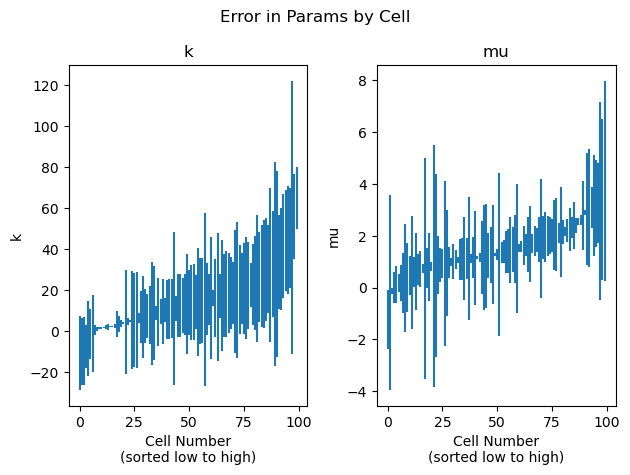

In [24]:
# Creating a scatter plot where cells are ranked by variance on y and x is tuning mu
fig,axes = plt.subplots(1,len(param_str))

for i,ax in enumerate(axes): 
    # Sort by parameter low to high
    copy_df = param_df.sort_values(by=[param_str[i]+ "_mean"])
    
    means = copy_df[param_str[i] + "_mean"]
    err = copy_df[param_str[i] + "_ci"]

    yerr = [
    [mean - ci[0] for mean, ci in zip(means, err)],  # lower error
    [ci[1] - mean for mean, ci in zip(means, err)]   # upper error
    ]
    
    x_values = list(range(100))
    ax.errorbar(x_values, means, yerr=yerr, linestyle="")

    # Style 
    ax.set_title(param_str[i])
    ax.set_xlabel("Cell Number\n(sorted low to high)")
    ax.set_ylabel(param_str[i])
    fig.suptitle("Error in Params by Cell")
    fig.tight_layout()
    
    # Save figure
    plt.savefig(fig_dir + '\\error_by_params_vm.png')

## Cosine Fit

### Standard Cosine

In [35]:
# Allocating variables for tuning curve fitting
points_in_fit = 300

# y-values of fit 
fit_response = np.ndarray((2,num_cells,points_in_fit)) # first dimension is 2 to store pre and post fits
A_fit = np.ndarray((2,num_cells))
theta_0_fit = np.ndarray((2,num_cells))
B_fit = np.ndarray((2,num_cells))

# x-value for the fit 
#theta_fit = np.linspace(0, np.pi*5/6, 300)  # 0° to 180° in radians
theta_fit = np.linspace(0, 2*np.pi, 300)  # 0° to 180° in radians

# Alt. width parameter 
fwhm_cos = np.ndarray((2,num_cells))

In [36]:
# Creating fitting code 
# Looping through pre and post to get measures for both
#for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
    # Iterate through each cell
    for i in range(data.shape[0]):

        # Step 1: Input your data
        responses = data[i,:]
        
        # Convert to radians
        orientations_rad = np.deg2rad(orientations)

        # Step 2: Define von Mises tuning function
        def cosine_tuning(theta, theta_0, A, B):
            return A * np.cos(2*(theta-theta_0)) + B

        # Step 3: Initial parameter guess: [A, kappa, mu, B]
        A = np.max(responses) - np.min(responses)
        theta_0 = orientations_rad[np.argmax(responses)]
        B = np.min(responses)
        initial_guess = [A, theta_0, B]

        try:
            # Step 4: Curve fitting
            params, _ = curve_fit(cosine_tuning, orientations_rad, responses, p0=initial_guess)
            A_fit[i_data,i], theta_0_fit[i_data,i], B_fit[i_data,i] = params

            # Step 5: Plot result
            fit_response[i_data,i,:] = cosine_tuning(theta_fit, *params)

            # Calculate the FWHM for each cell
            peak_val = fit_response[i_data,i,:].max()
            peak_ind = np.abs(fit_response[i_data,i,:] - peak_val).argmin()
            half_max = peak_val / 2

            # Calculating indices where x-values of data-points would be 
            half_ind = np.abs(fit_response[i_data,i,:] - half_max).argmin()
            
            # Assuming (for now) fits are symmetric so can double HWHM
            fwhm_cos[i_data,i] = (theta_fit[peak_ind] - theta_fit[half_ind])*2

        except RuntimeError:
            fit_response[i_data,i,:] = [np.nan]*points_in_fit  
            fwhm_cos[i_data,i] = np.nan

#### Checking fit quality

<ErrorbarContainer object of 3 artists>

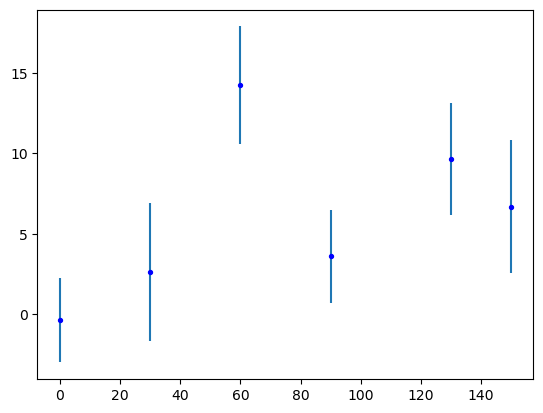

In [18]:
# Checking why error bars are so small, turns out it is just a y-scale issue
test = pre_data[3,:,:]
err = stats.sem(test,axis=1)
means = test.mean(axis=1)
fig,ax = plt.subplots()
ax.scatter(orientations, means, color='b', zorder=5, s=8, label="ΔF/F Data")
ax.errorbar(orientations, means, yerr=err, linestyle="")

In [37]:
fwhm_cos = np.abs(np.rad2deg(fwhm_cos)) 

# Calculating indices where x-values of data-points would be 
indices = np.array([np.abs(np.rad2deg(theta_fit) - ori).argmin() for ori in orientations])

# Variance Accounted For (VAF) or R^2 (?)
pre = 0 # accessing pre data in fit, needed to gather FWHM pre post in above loop
vaf = [(1 - np.var(visResp_behavStim_pre[cell,:] - fit_response[pre,cell,indices])/np.var(visResp_behavStim_pre[cell,:]))*100 for cell in range(num_cells)]

# Calculating goodness of fit as described by Swindale et al. 1998:https://link.springer.com/article/10.1007/s004220050411
# Step one 
y = np.ndarray((2,num_cells,orientations.shape[0]))
rms = np.ndarray((2,num_cells))
for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
    for i_cell in range(num_cells):
        R = visResp_behavStim_pre[i_cell,:]
        f = fit_response[i_data,i_cell,indices]
        A = A_fit[i_data,i_cell]
        y[i_data,i_cell,:] = 100*(R-f)/A
        y_sq = [x**2 for x in y[i_data,i_cell,:]]
        rms[i_data,i_cell] = np.sqrt(np.sum(y_sq)/len(y_sq))
        
        
# Print metrics of fitting
num_cells_fit = len(np.where(~np.isnan(fwhm_cos[0,:]))[0])
p_cells_fit = num_cells_fit/num_cells*100
count_vaf_threshold = np.where(np.array(vaf)>80)[0].shape[0]
avg_rms = rms[0,:].mean()

print("Cells fit succesfully: %i" %num_cells_fit)
print("Percent of cells fit: %i%%" %p_cells_fit)
print("Average variance accounted for: %.2f%%" %np.nanmean(vaf)) 
print("Cells above 80%% vaf: %i" %count_vaf_threshold)
print("Average normalized RMS value: %.2f" %avg_rms)


Cells fit succesfully: 100
Percent of cells fit: 100%
Average variance accounted for: 51.68%
Cells above 80% vaf: 19
Average normalized RMS value: 24.86


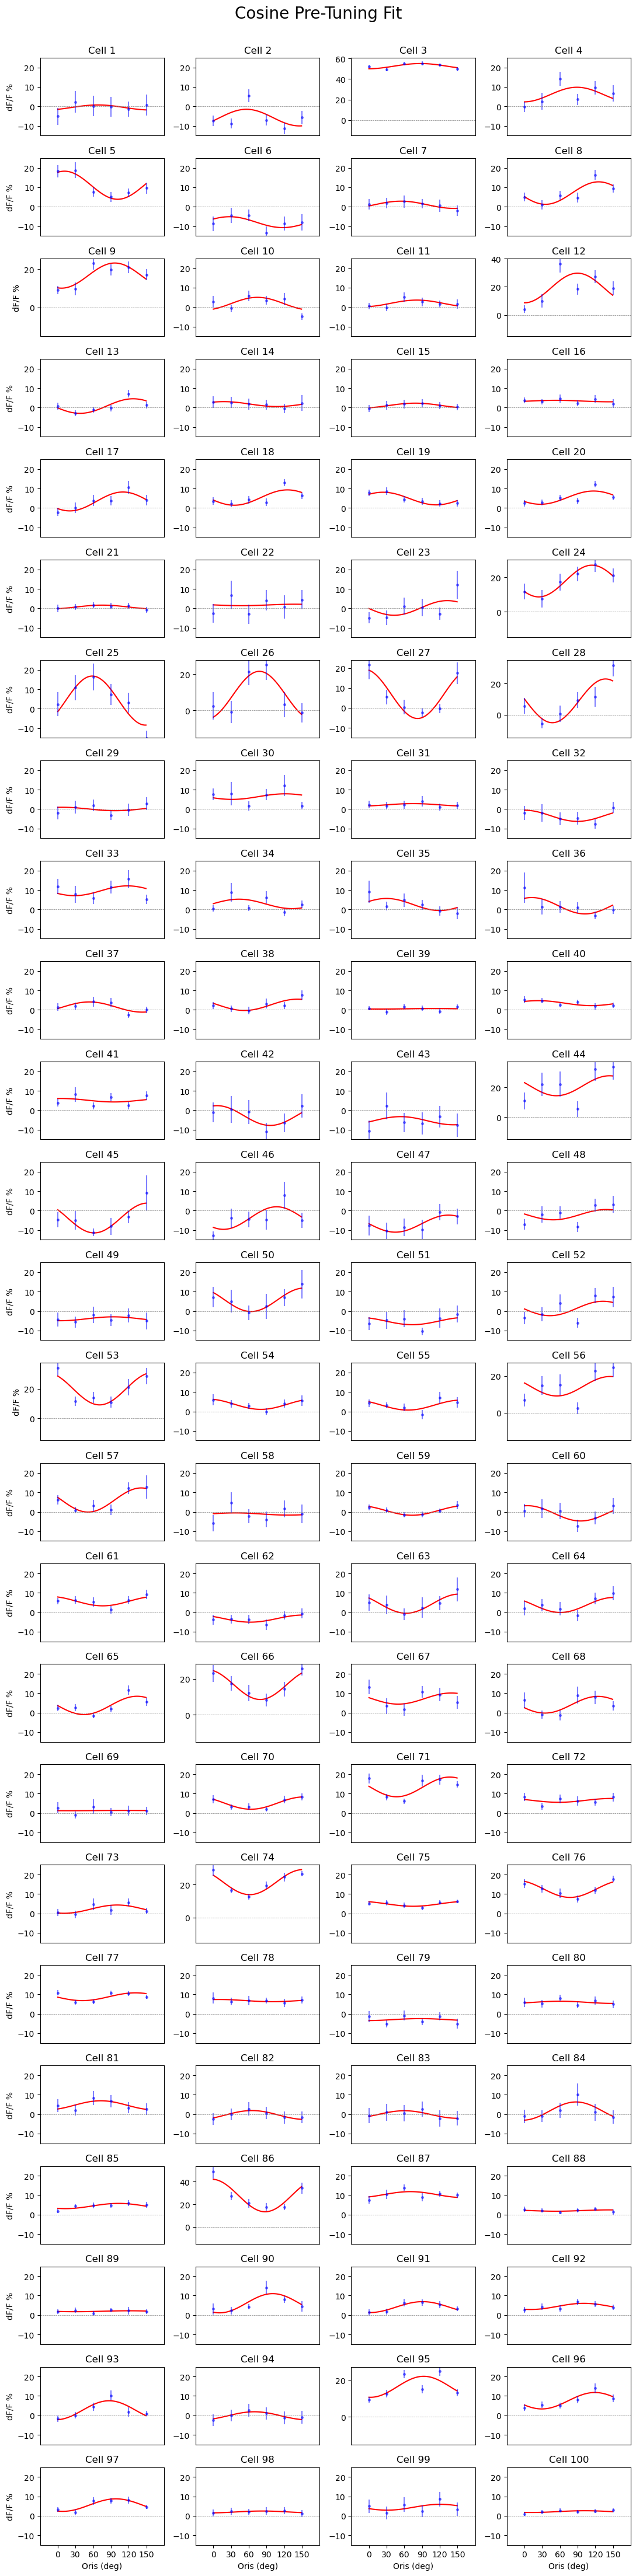

In [39]:
# Plotting the tuning fit for each cell
from scipy.optimize import curve_fit

# Set the dimensions of the subplot grid
cols = 4
rows = int(np.ceil(num_cells/cols))

# Create a figure and a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(11, 45))
axes = axes.flatten() # to make iterable

# Step 1: Input your data
orientations_rad = np.deg2rad(orientations)

x_labels = [str(i) for i in orientations]

# Iterate through each subplot
for i in range(num_cells):

    responses = visResp_behavStim_pre[i,:]
    err = pre_err[i,:]
    
    ax = axes[i]
    end_ind = np.argmin(np.abs(theta_fit-np.pi*5/6))
    ax.plot(theta_fit[0:end_ind], fit_response[0,i,0:end_ind], 'r-', label="Fit") # 0 ind is 1 is post
    # ax.scatter(orientations_rad, responses, color='b', zorder=5, s=8, label="ΔF/F Data")
    ax.errorbar(orientations_rad, responses, yerr=err, marker=".", markersize=5, color = "blue", alpha = 0.5, linestyle="")
    ax.axhline(0, color='gray',lw=0.5,linestyle='--')
    ax.set_xlim([-np.pi/6, np.pi])
    ax.set_title(f'Cell {i + 1}', fontsize=12)
    # ax.text(orientations_rad[3],40,"vaf=%.1f%%" %vaf[i])
    # ax.text(orientations_rad[3],32,"fwhm=%.2f" %fwhm_vm[0,i])

    # ax.set_xticks(
    #     ticks=[0, np.pi*0.5, np.pi],
    #     labels=["-90\u00b0", "trained\nori", "90\u00b0"])
    
    if i == 0:
        ax.set_ylabel('\u0394dF/F%')
        
    # Code to set the ylims based on values with a minimum of 25% 
    if any(responses > 20):
        y_max = np.max(responses)*1.1 # Making max ylim 1.1 
        ax.set_ylim([-15,y_max])
        
    else: 
        ax.set_ylim([-15, 25])  
    
    # # Code to set the ylims based on values with a minimum of 25% 
    # if any(visResp_behavStim_pre[i,:] > 50):
    #     limit = visResp_behavStim_pre[i,:]*1.1 # Making max ylim 1.1 
    #     y_max_ind = np.argmax(abs(limit)) 
        
    #     if limit[y_max_ind] > 0: 
    #         ax.set_ylim([-50,limit[y_max_ind]])
    #     else:
    #         ax.set_ylim([limit[y_max_ind],50])
    # else: 
    #     ax.set_ylim([-30, 50])   
        
    # Setting only the first column to have y labels 
    if np.remainder(i,cols) == 0:
        ax.set_ylabel("dF/F %")
  
    if (rows*cols) - i - 1< cols:
        ax.set_xlabel("Oris (deg)")
        ax.set_xticks(
            ticks=orientations_rad,
            labels=x_labels)
    else: 
        ax.set_xticks(
            ticks=[],
            labels=[])

    # if i > 51 and i <56:
    #         ax.set_xticks(
    #     ticks=orientations_rad,
    #     labels=x_labels)
    # if i == 52:
    #     ax.set_xlabel("Ori. (deg)")
# Removing axes greater than the number of cells 
for ind in range(rows*cols - num_cells):
    ax = axes[num_cells + ind]
    ax.axis('off') 

plt.rcParams.update({'font.size': 10}) 
plt.tight_layout()
fig.suptitle("Cosine Pre-Tuning Fit", fontsize = 20)
fig.subplots_adjust(top=0.96)

# Save figure
plt.savefig(fig_dir + '\\cos_fit.png')

plt.show()

### Bootstrapping Cosine Fit

In [54]:
# Allocating variables for tuning curve fitting
# where "2", makes space for pre and post data 

# Constants
points_in_fit = 300
bootstrapping_n = 10

# y-values of fit 
fit_response = np.ndarray((bootstrapping_n,2,num_cells,points_in_fit)) # first dimension is 2 to store pre and post fits
# x-value for the fit 
# theta_fit = np.linspace(0, np.pi*5/6, 300)  # 0° to 180° in radians
theta_fit = np.linspace(0, 2*np.pi, 300)  

A_fit = np.ndarray((bootstrapping_n,2,num_cells))
theta_0_fit = np.ndarray((bootstrapping_n,2,num_cells))
B_fit = np.ndarray((bootstrapping_n,2,num_cells))

# Alt. width parameter 
fwhm_cos = np.ndarray((bootstrapping_n,2,num_cells))
# quality of fit measure 
vaf = np.ndarray((bootstrapping_n,2,num_cells))


In [55]:
# Looping through pre and post to get measures for both
#for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
for i_iter in range(bootstrapping_n):

    # Calculate new resampled data each iteration 
    pre_averages = sample_w_replacement(pre_data,orientations,visResp_behavStim_pre.shape)
    post_averages = sample_w_replacement(post_data,orientations,visResp_behavStim_post.shape)
        
    for i_data, data in enumerate([pre_averages,post_averages]):
        # Iterate through each cell
        for i_cell in range(data.shape[0]):
    
            # Input your data
            responses = data[i_cell,:]
            
            # Convert to radians
            orientations_rad = np.deg2rad(orientations)
        
            # Step 2: Define von Mises tuning function
            def cosine_tuning(theta, theta_0, A, B):
                return A * np.cos(2*(theta-theta_0)) + B
    
            # Step 3: Initial parameter guess: [A, kappa, mu, B]
            A = np.max(responses) - np.min(responses)
            theta_0 = orientations_rad[np.argmax(responses)]
            B = np.min(responses)
            initial_guess = [A, theta_0, B]
    
            try:
                # Step 4: Curve fitting
                params, _ = curve_fit(cosine_tuning, orientations_rad, responses, p0=initial_guess)
                A_fit[i_iter,i_data,i_cell], theta_0_fit[i_iter,i_data,i_cell], B_fit[i_iter,i_data,i_cell] = params
    
                # Step 5: Plot result
                fit_response[i_iter,i_data,i_cell,:] = cosine_tuning(theta_fit, *params)
                
                current_fit = fit_response[i_iter,i_data,i_cell,:] # to improve readability below
           
            # If fit cannot be found, store nan 
            except RuntimeError:
                fit_response[i_iter,i_data,i_cell,:] = [np.nan]*points_in_fit  
        

#### Plot variance of estimated parameters

In [56]:
# Calculating a confidence interval for the boostrapped parameters for each cell
# Then store statistics for each parameter in a dataframe 

# Define parameters of interest + create dataframe to store
param_str = ["A","theta_0","B"]
units = ["(df/f%)","(deg)","(df/f%)"]

df_columns = []
for param in param_str:
    df_columns.append(param + '_mean')
    df_columns.append(param + '_sem')
    df_columns.append(param + '_ci')

# Creating a pandas dataframe for each param and it's stats: cell on rows kappa, mu with mean and ci as columns
param_df = pd.DataFrame(columns = df_columns)
params = [A_fit,theta_0_fit,B_fit]

# Set CI confidence level 
confidence_level = 0.95

# Calculaing CIs for each desired parameter of the fit 
for i, param in enumerate(param_str):
    mean_store = []
    sem_store = []
    ci_store = []

    param_data = params[i]

    if param == "theta_0":
        param_data = np.rad2deg(param_data)

    # Loop over each cell, calculate stats then append 
    for cell_ind in range(pre_averages.shape[0]):
        
        # Calculating CI for kappa 
        cell_data = param_data[:,0,cell_ind]
        mean = np.mean(cell_data)
        sem = stats.sem(cell_data)
        
        ci = stats.t.interval(confidence_level, len(cell_data)-1, loc=mean, scale=sem)

        mean_store.append(mean)
        sem_store.append(sem)
        ci_store.append(ci)

    # Storing parameter statisitics in df
    param_df[param + "_mean"] = mean_store
    param_df[param + "_sem"] = sem_store
    param_df[param + "_ci"] = ci_store

# Save the pandas array for this bootstrapping 
param_df.to_pickle(base_dir + "\\general_data_struct\\cosine_param_df.pkl")

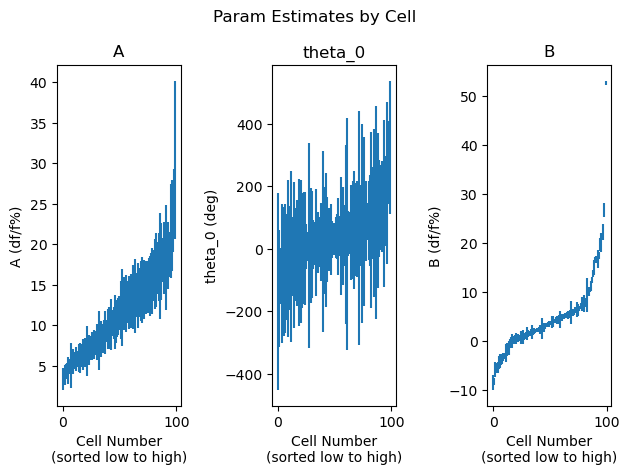

In [57]:
# Loading in the param_df 
with open(base_dir + "\\general_data_struct\\cosine_param_df.pkl", 'rb') as file:
    param_df = pickle.load(file)

# Define parameters of interest
param_str = ["A","theta_0","B"]
units = ["(df/f%)","(deg)","(df/f%)"]

# Creating a scatter plot where cells are ranked by variance on y and x is tuning mu
fig,axes = plt.subplots(1,len(param_str))

for i,ax in enumerate(axes): 
    # Sort by parameter low to high
    copy_df = param_df.sort_values(by=[param_str[i]+ "_mean"])
    
    means = copy_df[param_str[i] + "_mean"]
    err = copy_df[param_str[i] + "_ci"]

    yerr = [
    [mean - ci[0] for mean, ci in zip(means, err)],  # lower error
    [ci[1] - mean for mean, ci in zip(means, err)]   # upper error
    ]
    
    x_values = list(range(100))
    ax.errorbar(x_values, means, yerr=yerr, linestyle="")

    # Style 
    ax.set_title(param_str[i])
    ax.set_xlabel("Cell Number\n(sorted low to high)")
    ax.set_ylabel(param_str[i] +" "+units[i])
    fig.suptitle("Param Estimates by Cell")
    fig.tight_layout()

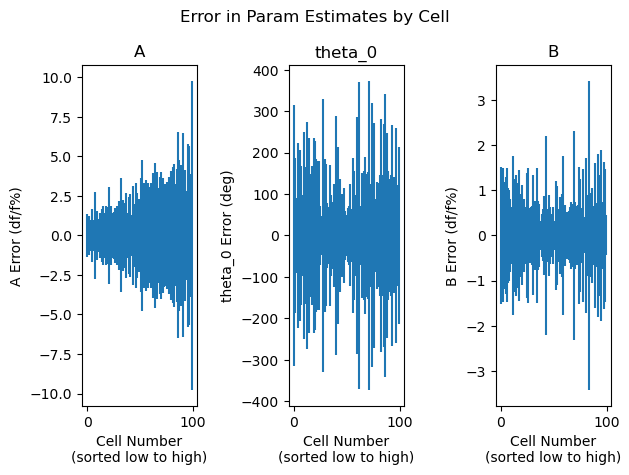

In [59]:
# Plotting a distribution of the variance for each measure 
# Creating a scatter plot where cells are ranked by variance on y and x is tuning mu
fig,axes = plt.subplots(1,len(param_str))

for i,ax in enumerate(axes): 
    # Sort by parameter low to high
    copy_df = param_df.sort_values(by=[param_str[i]+ "_mean"])
    
    means = copy_df[param_str[i] + "_mean"]
    err = copy_df[param_str[i] + "_ci"]

    yerr = [
    [mean - ci[0] for mean, ci in zip(means, err)],  # lower error
    [ci[1] - mean for mean, ci in zip(means, err)]   # upper error
    ]
    
    x_values = list(range(100))
    ax.errorbar(x_values, np.zeros_like(x_values), yerr=yerr, linestyle="")

    # Style 
    ax.set_title(param_str[i])
    ax.set_xlabel("Cell Number\n(sorted low to high)")
    ax.set_ylabel(param_str[i] + " Error" + " " + units[i])
    fig.suptitle("Error in Param Estimates by Cell")
    fig.tight_layout()
    
# Save figure
plt.savefig(fig_dir + '\\param_err_cos.png')

#### Plot relationship between outcome and fit parameters of pre-vis data

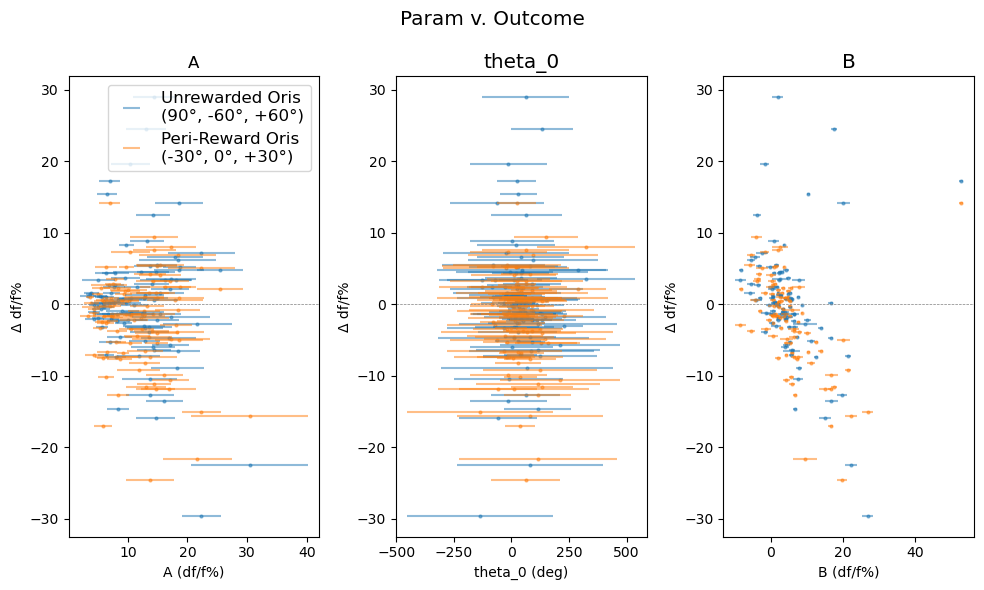

In [60]:
non_peri_rew = np.mean(dfoF_V_change_bhStim[:,[0,1,5]],axis=1) # inds of nonperireward oris
peri_rew = np.mean(dfoF_V_change_bhStim[:,2:4],axis=1)

# Creating a scatter plot where cells are ranked by variance on y and x is tuning mu
fig,axes = plt.subplots(1,len(param_str),figsize=(10,6))

for i,ax in enumerate(axes): 
   
    means = param_df[param_str[i] + "_mean"]
    err = param_df[param_str[i] + "_ci"]

    yerr = [
    [mean - ci[0] for mean, ci in zip(means, err)],  # lower error
    [ci[1] - mean for mean, ci in zip(means, err)]   # upper error
    ]
    
    ax.errorbar(means, non_peri_rew, xerr=yerr, alpha = 0.5, label="Unrewarded Oris\n(90°, -60°, +60°)", linestyle="")
    ax.errorbar(means, peri_rew, xerr=yerr, alpha = 0.5, label="Peri-Reward Oris\n(-30°, 0°, +30°)", linestyle="")

    
    # Plotiting the non-perireward oris
    ax.scatter(means,non_peri_rew,alpha = 0.5, s=4)
    ax.scatter(means,peri_rew,alpha = 0.5, s=4)

    #Plotiting the non-perireward oris

    # Style 
    ax.set_title(param_str[i])
    ax.set_ylabel("Δ df/f%")
    ax.set_xlabel(param_str[i] + " " + units[i])
    ax.axhline(0,color="grey",linestyle="--",linewidth=0.5)
    fig.suptitle("Param v. Outcome")
    plt.rcParams.update({'font.size': 12})
    fig.tight_layout()

axes[0].legend()

# # Formatting 
# plt.text(180,14,"N=%i" % len(delta_fwhm))
# plt.xlabel("Change in Tuning Width (Δdeg)")
# plt.ylabel("Δ dF/f%")
# plt.title("Change in Tuning Width v. Change in Response")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# Save figure
plt.savefig(fig_dir + '\\param_v_outcome_cos.png')

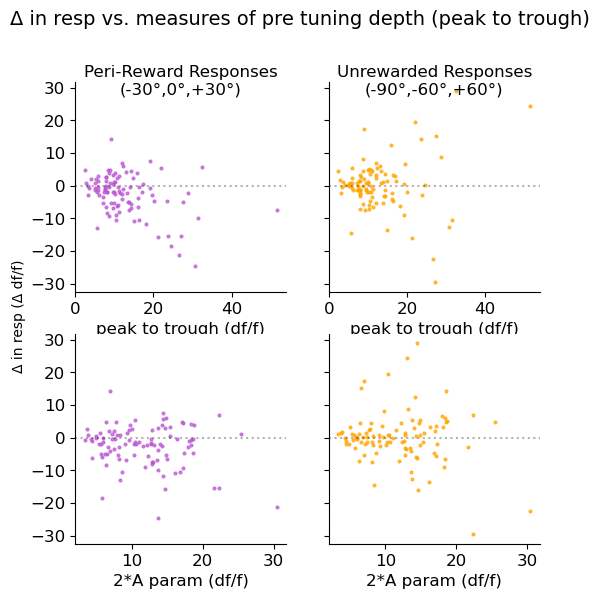

In [61]:
# Plotting max-min amp versus our estimate

peak_to_trough = -(dfoF_V_change_bhStim.min(axis=1)-dfoF_V_change_bhStim.max(axis=1))
fig,ax= plt.subplots(2,2,figsize=(6,6),sharey=True); font = {'size'   : 10}; mpl.rc('font', **font);ax=ax.ravel()
ax = ax.ravel()
nonrew = np.array([dfoF_V_change_bhStim[:,0],dfoF_V_change_bhStim[:,1],dfoF_V_change_bhStim[:,5]]).mean(axis=0)
rew = dfoF_V_change_bhStim[:,2:5].mean(axis=1)
means = param_df["A_mean"]

ax[0].scatter(peak_to_trough,rew, alpha=0.7, c='mediumorchid', s=4);ax[0].set_title('Peri-Reward Responses\n(-30°,0°,+30°)',y=0.9);ax[0].set_xlabel("peak to trough (df/f)")
ax[1].scatter(peak_to_trough,nonrew, alpha=0.7, c='orange', s=4);ax[1].set_title('Unrewarded Responses\n(-90°,-60°,+60°)',y=0.9,x=0.5);ax[1].set_xlabel("peak to trough (df/f)")
ax[2].scatter(means,rew,alpha = 0.7,c='mediumorchid', s=4, label="Peri-Reward Oris\n(-30°, 0°, +30°)"); ax[2].set_xlabel("2*A param (df/f)")
ax[3].scatter(means,nonrew,alpha=0.7, c='orange', s=4, label="Non-Peri-Reward Oris\n(-90°,-60°,+60°)"); ax[3].set_xlabel("2*A param (df/f)")

# # Find cell at -20 rew 
# ind = np.argmin(np.abs(rew+10))
# ax[0].scatter(peak_to_trough[ind],rew[ind], alpha=0.7, c='black', s=4); #ax[0].set_xlabel("peak to trough")
# ax[1].scatter(peak_to_trough[ind],nonrew[ind], alpha=0.7, c='black', s=4)
# ax[2].scatter(2*means[ind],rew[ind], alpha=0.7, c='black', s=4); #ax[2].set_xlabel("A param")
# ax[3].scatter(2*means[ind],nonrew[ind], alpha=0.7, c='black', s=4)

fig.suptitle("Δ in resp vs. measures of pre tuning depth (peak to trough)",fontsize=14,y=1)
# fig.text(0.4,0.475,"peak to trough (df/f)"); fig.text(0.45,0.05,"A param (df/f)");
fig.text(0.02,0.4,'Δ in resp (Δ df/f)',rotation='vertical')

[a.axhline(c='black',alpha=0.3,ls=':') for a in ax.ravel()];

[a.spines['top'].set_visible(False) for a in ax.ravel()]; [a.spines['right'].set_visible(False) for a in ax.ravel()];

# Save figure
plt.savefig(fig_dir + '\\param_v_outcome_cos.png')

## Circular Variance (experimental - not fully tested)
A fitless measure of tuning width

In [ ]:
# Calculating circular variance instead of curve fitting
cv = np.ndarray((2,no_qc_vis_pre.shape[0]))

# Looping through pre and post to get measures for both
#for i_data, data in enumerate([visResp_behavStim_pre,visResp_behavStim_post]):
for i_data, data in enumerate([no_qc_vis_pre,visResp_behavStim_post[~qc_inds_pre]):
    # Iterate through each cell
    for i in range(data.shape[0]):

        # Step 1: Input your data
        responses = data[i,:]
        # Convert to radians
        orientations_rad = np.deg2rad(orientations)
        # Calc and store
        cv[i_data,i] = circular_variance(orientations_rad, responses)


In [ ]:
# Code from HM on calculating circular variance

## Normalize
normalizeDFF=True #Sometimes its useful to normalize your data so that there are no negative values,
                   #which can produce CVs with negative values or >1. This normalizes data so the minimum response is
                   # zero, and the maximum response is 1.

pre_CV = []
pre_dirCV = []
post_CV = []
post_dirCV = []

dirs = orientations
for i_data, data in enumerate([no_qc_vis_pre,visResp_behavStim_post[~qc_inds_pre]]):
    
    cell_CVs=[]
    cell_dirCVs=[]
    
    for icell,cell_resp in enumerate(data):
        if normalizeDFF:
            cell_resp=(cell_resp-np.min(cell_resp))/(np.max(cell_resp)-np.min(cell_resp))
        a=[]
        for idir,resp in enumerate(cell_resp):
            a.append(resp*np.exp(2*1j*np.deg2rad(dirs[idir])))
            
        cell_CVs.append(1-np.linalg.norm(np.sum(a)/np.sum(cell_resp)))
    
        a=[]
        for idir,resp in enumerate(cell_resp):
            a.append(resp*np.exp(1j*np.deg2rad(dirs[idir])))
            
        cell_dirCVs.append(1-np.linalg.norm(np.sum(a)/np.sum(cell_resp)))

    if i_data == 0:
        pre_dirCV = cell_dirCVs
        pre_CV = cell_CVs
    elif i_data == 1:
        post_dirCV = cell_dirCVs
        post_CV = cell_CVs

In [ ]:
# Plot histogram of circular variance 

fig,ax = plt.subplots(figsize = (5,5))

plt.hist(pre_dirCV, range = (0,1), alpha = 0.5, label = "Pre", bins = 30)
plt.hist(post_dirCV, range = (0,1), alpha = 0.5, label = "Post", bins = 30)

# Add labels and title
plt.xlabel('Circular Variance')
plt.ylabel('Frequency')
plt.title('Circular Variance (Pre and Post)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
plt.legend(loc='upper right')

# Show the plot
plt.show()

In [ ]:
# Creating a box and whisker plot of circvar 
fig,ax = plt.subplots(figsize =(5, 5))

no_nan_i = ~np.isnan(fwhm_vm)
plt.boxplot([pre_dirCV,post_dirCV])
plt.title("Tuning Width (CircVar, N=%i)" %len(pre_CV))
plt.xticks([1,2],["Pre","Post"])
plt.ylabel("Circular Variance")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [ ]:
# Combined orientation average against circular variance

# Filtering pre quiet cells out of change data 
no_qc_pre_change = dfoF_V_change_bhStim[~qc_inds_pre,:]
check = np.nanmean(no_qc_pre_change[:,[0,1,5]],axis=1) # inds of nonperireward oris

# Creating a scatter plot of tuning width change and suppression and enhancement
delta_fwhm = np.array(post_dirCV)-np.array(pre_dirCV)

fig, ax = plt.subplots()

# Plotiting the non-perireward oris
plt.scatter(delta_fwhm,check,alpha = 0.5, label="Non Peri-Reward Oris\n(90°, +60°, -60°)")

# Taking mean of perireward oris 
change_filt = np.nanmean(no_qc_pre_change[:,2:4],axis=1)

# Plotiting the non-perireward oris
plt.scatter(delta_fwhm,change_filt,alpha = 0.5,label="Peri-Reward Oris\n(-30°, 0°, +30°)")

# Formatting 
#plt.text(180,14,"N=%i" % len(delta_fwhm))
plt.xlabel("Change in Tuning Width (ΔCirc Var)")
plt.ylabel("Δ dF/f%")
plt.title("Change in Tuning Width v. Change in Response")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axhline(0,color="grey",linestyle="--",linewidth=0.5)
plt.legend()


## Tuning Width Plots
This code will only run for the non-bootrapped data structures, but it can be updated for bootstrapped resamples. Will need to re-run standard fitting for this to work.

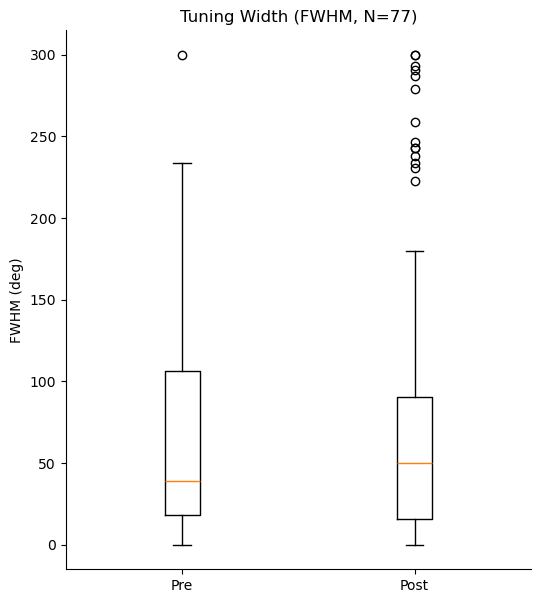

In [26]:
# Creating a box and whisker plot of tuning width
fig,ax = plt.subplots(figsize =(6, 7))
# Can plot only cells that were fit, others do not have tuning width
no_nan_i = ~np.isnan(fwhm_vm)
plt.boxplot([fwhm_vm[0,no_nan_i[0]],fwhm_vm[1,no_nan_i[1]]])
plt.title("Tuning Width (FWHM, N=%i)" %len(fwhm_vm[0,no_nan_i[0]]))
plt.xticks([1,2],["Pre","Post"])
plt.ylabel("FWHM (deg)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

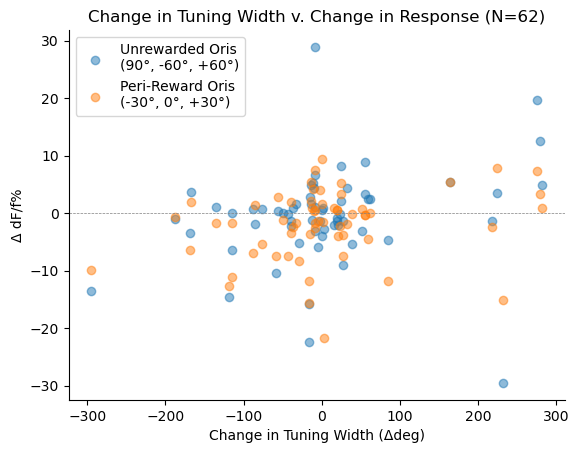

In [27]:
# Combined orientation average against tuning width

# Finding cells that are fit in both cases
inds = np.logical_and(no_nan_i[0],no_nan_i[1])

# Avg unrew
unrew = np.nanmean(dfoF_V_change_bhStim[:,[0,1,5]],axis=1) # inds of nonperireward oris

# Creating a scatter plot of tuning width change and suppression and enhancement
delta_fwhm = fwhm_vm[1,inds] - fwhm_vm[0,inds]

fig, ax = plt.subplots()

# Plotiting the unrew oris
plt.scatter(delta_fwhm,unrew[inds],alpha = 0.5, label="Unrewarded Oris\n(90°, -60°, +60°)")

# Taking mean of perireward oris 
rew  = np.nanmean(dfoF_V_change_bhStim[inds,2:4],axis=1)

# Plotiting the non-perireward oris
plt.scatter(delta_fwhm,rew,alpha = 0.5,label="Peri-Reward Oris\n(-30°, 0°, +30°)")

# Formatting 
#plt.text(180,14,"N=%i" % len(delta_fwhm))
plt.xlabel("Change in Tuning Width (Δdeg)")
plt.ylabel("Δ dF/f%")
plt.title("Change in Tuning Width v. Change in Response (N=%i)" % len(delta_fwhm))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axhline(0,color="grey",linestyle="--",linewidth=0.5)
plt.legend()


### Code below splits the above plot

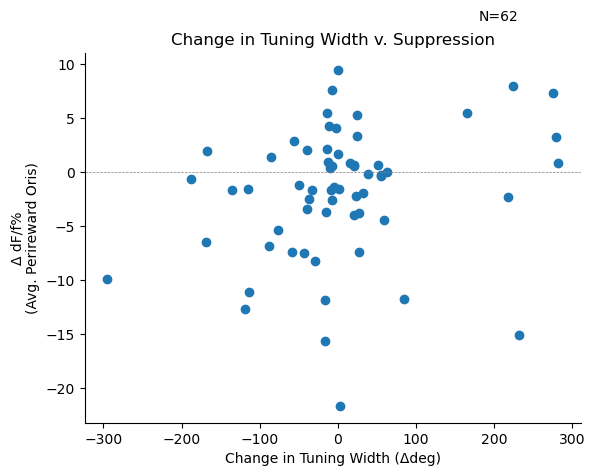

In [40]:
# Finding cells that are fit in both cases 
inds = np.logical_and(no_nan_i[0],no_nan_i[1])

# Filtering pre quiet cells out of change data 
change_filt = np.nanmean(dfoF_V_change_bhStim[inds,2:4],axis=1)

# Creating a scatter plot of tuning width change and suppression and enhancement
delta_fwhm = fwhm_vm[1,inds] - fwhm_vm[0,inds]

fig, ax = plt.subplots()

plt.scatter(delta_fwhm,change_filt)
plt.text(180,14,"N=%i" % len(delta_fwhm))
plt.xlabel("Change in Tuning Width (Δdeg)")
plt.ylabel("Δ dF/f%\n(Avg. Perireward Oris)")
plt.title("Change in Tuning Width v. Suppression")
plt.axhline(0,color="grey",linestyle="--",linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.plot(

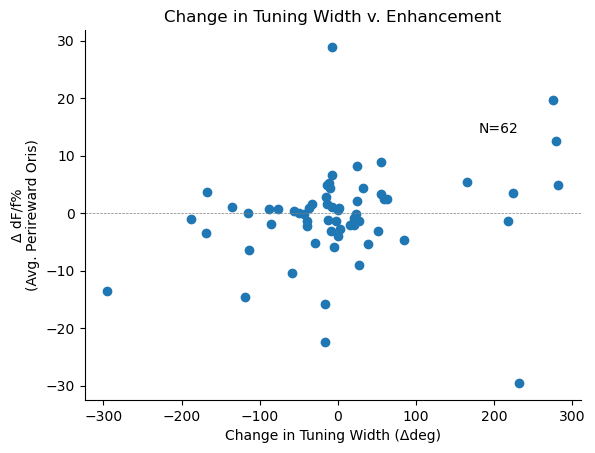

In [41]:
# Finding cells that are fit in both cases
inds = np.logical_and(no_nan_i[0],no_nan_i[1])

# Filtering pre quiet cells out of change data 
check = np.nanmean(dfoF_V_change_bhStim[:,[0,1,5]],axis=1)
# Creating a scatter plot of tuning width change and suppression and enhancement
delta_fwhm = fwhm_vm[1,inds] - fwhm_vm[0,inds]

fig, ax = plt.subplots()

plt.scatter(delta_fwhm,check[inds])

plt.text(180,14,"N=%i" % len(delta_fwhm))
plt.xlabel("Change in Tuning Width (Δdeg)")
plt.ylabel("Δ dF/f%\n(Avg. Perireward Oris)")
plt.title("Change in Tuning Width v. Enhancement")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.axhline(0,color="grey",linestyle="--",linewidth=0.5)

# plt.plot(

### Histogram

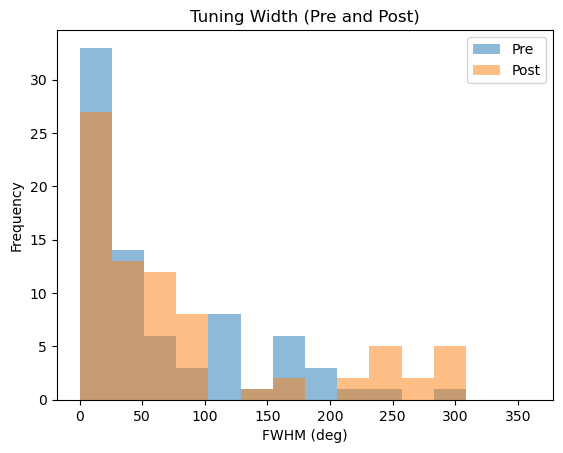

In [43]:
plt.hist(fwhm_vm[0,no_nan_i[0]], range = (0,360), alpha = 0.5, label = "Pre", bins = 14)
plt.hist(fwhm_vm[1,no_nan_i[1]], range = (0,360), alpha = 0.5, label = "Post", bins = 14)

# Add labels and title
plt.xlabel('FWHM (deg)')
plt.ylabel('Frequency')
plt.title('Tuning Width (Pre and Post)')

# Add legend
plt.legend(loc='upper right')

# Show the plot
plt.show()

# Average Tuning Plots

### Standard + Without Quiet Cells

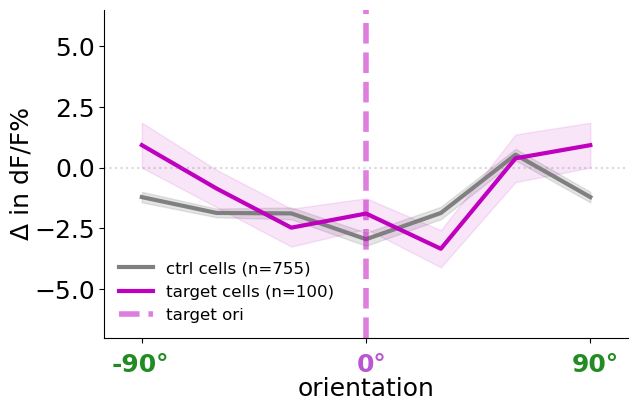

In [10]:
avg_ctrl = np.nanmean(dfoF_V_change_ctrl, axis=0)
avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
avg_bhStim = np.nanmean(dfoF_V_change_bhStim, axis=0)
avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))

sem_ctrl = stats.sem(dfoF_V_change_ctrl, axis=(0),nan_policy='omit')
sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))
sem_bhStim = stats.sem(dfoF_V_change_bhStim, axis=(0),nan_policy='omit')
sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))

difs = [avg_ctrl, avg_bhStim]

fig= plt.figure(figsize=(12,8))
#fig.text(0.5, 0.435, '*sub selected visually responsive (df/f>7)\nnot stimd cell pop to match mean vis resp of stimd cells', ha='left', va='center', fontsize=10)
colors = ['grey', 'm']
font = {'size'   : 18}
mpl.rc('font', **font)
#fig.text(0.52, 0.44, 'orientation', ha='center', va='center')
xs = [0,1,2,3,4,5,6]

ax1 = fig.add_subplot(221+1)
ax1.plot(difs[0],color=colors[0],lw=3,label='ctrl cells (n=%i)' %dfoF_V_change_ctrl.shape[0])
ax1.plot(difs[1],color=colors[1],lw=3,label='target cells (n=%i)' %dfoF_V_change_bhStim.shape[0])
ax1.fill_between(xs,difs[0]+sem_ctrl,difs[0]-sem_ctrl,color=colors[0],alpha=0.2)
ax1.fill_between(xs,difs[1]+sem_bhStim,difs[1]-sem_bhStim,color=colors[1],alpha=0.1)
ax1.set_xlabel('orientation')
ax1.set_xticks([0,3,6]); ax1.set_xticklabels([' ',' ',' '])
ax1.text(-0.4,-8.4,'-90°',c='forestgreen',weight='semibold')
ax1.text(2.88,-8.4,'0°',c='mediumorchid',weight='semibold')
ax1.text(5.75,-8.4,'90°',c='forestgreen',weight='semibold')
ax1.set_ylabel('Δ in dF/F%',labelpad= 0)
ax1.set_ylim([-7,6.5])
ax1.set_xlim([-0.5,6.5])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axhline(c='grey',alpha=0.3,ls=':'); ax1.axvline(x=3,c=colors[1],alpha=0.5, ls='--',lw=4, label='target ori')
ax1.legend(loc='lower left',fontsize=12,frameon=False)
plt.subplots_adjust(wspace=None, hspace=None); plt.tight_layout()
#plt.savefig(file_path_save+'changeplot_wsem.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/friedmanng/Desktop/umd_nih/2024commeetee/changeplot_sup.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/phillipscm/Downloads/241021-figs/changeplot_tuncurve.png',bbox_inches='tight',dpi=400)

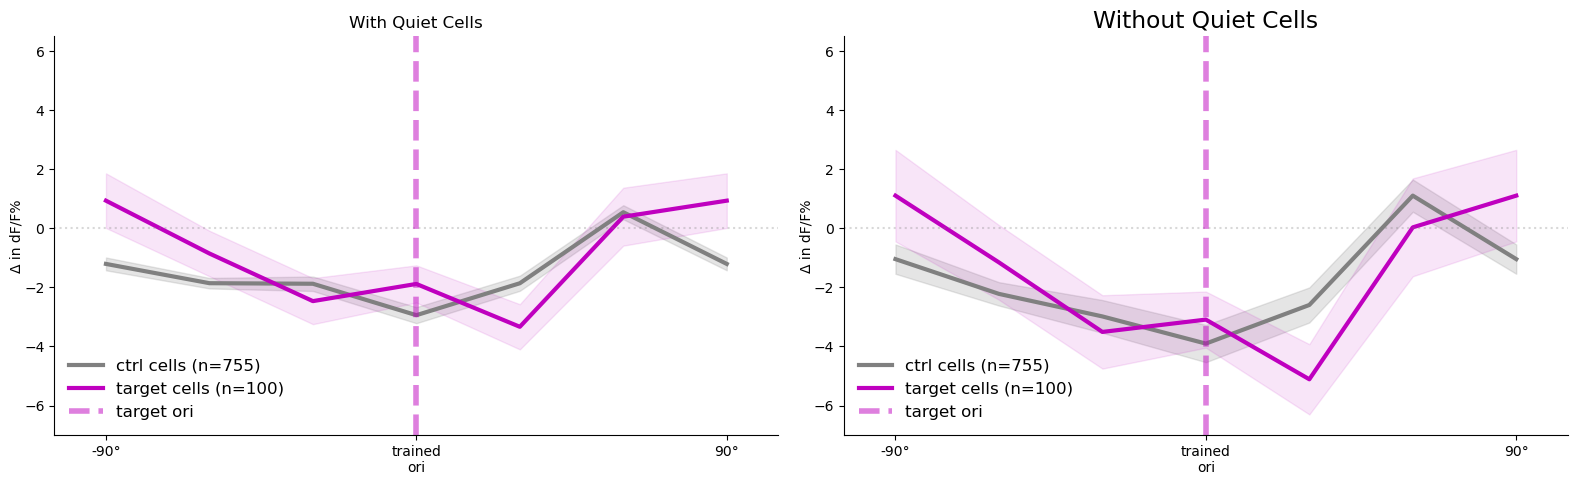

In [9]:
# Creates a plot of main result with and without trained cells that remained quiet, control quiet cells are still included

fig, axes = plt.subplots(1, 2, figsize=(16,5))
data_storage = [dfoF_V_change_ctrl,dfoF_V_change_bhStim]

for i, axis in enumerate(axes): 
    
    if i == 0:
        axis.set_title("With Quiet Cells")
        
        avg_bhStim = np.nanmean(dfoF_V_change_bhStim, axis=0)
        avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))
        sem_bhStim = stats.sem(dfoF_V_change_bhStim, axis=(0),nan_policy='omit')
        sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))

        avg_ctrl = np.nanmean(dfoF_V_change_ctrl, axis=0)
        avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
        sem_ctrl = stats.sem(dfoF_V_change_ctrl, axis=(0),nan_policy='omit')
        sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))

    else:
        axis.set_title("Without Quiet Cells")
        avg_bhStim = np.nanmean(dfoF_V_change_bhStim[~trained_stay_quiet_cells], axis=0)
        avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))
        sem_bhStim = stats.sem(dfoF_V_change_bhStim[~trained_stay_quiet_cells], axis=(0),nan_policy='omit')
        sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))

        avg_ctrl = np.nanmean(dfoF_V_change_ctrl[~ctrl_stay_quiet_cells], axis=0)
        avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
        sem_ctrl = stats.sem(dfoF_V_change_ctrl[~ctrl_stay_quiet_cells], axis=(0),nan_policy='omit')
        sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))

    difs = [avg_ctrl, avg_bhStim]

    colors = ['grey', 'm']
    font = {'size'   : 14}
    mpl.rc('font', **font)
    xs = [0,1,2,3,4,5,6]

    axis.plot(difs[0],color=colors[0],lw=3,label='ctrl cells (n=%i)' %dfoF_V_change_ctrl.shape[0])
    axis.plot(difs[1],color=colors[1],lw=3,label='target cells (n=%i)' %dfoF_V_change_bhStim.shape[0])
    axis.fill_between(xs,difs[0]+sem_ctrl,difs[0]-sem_ctrl,color=colors[0],alpha=0.2)
    axis.fill_between(xs,difs[1]+sem_bhStim,difs[1]-sem_bhStim,color=colors[1],alpha=0.1)
    axis.set_xticks(
        ticks=[0, 3, 6],
        labels=["-90\u00b0", "trained\nori", "90\u00b0"])
    axis.set_ylabel('Δ in dF/F%',labelpad= 0)
    axis.set_ylim([-7,6.5])
    axis.set_xlim([-0.5,6.5])
            
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.axhline(c='grey',alpha=0.3,ls=':'); axis.axvline(x=3,c=colors[1],alpha=0.5, ls='--',lw=4, label='target ori')
    axis.legend(loc='lower left',fontsize=12,frameon=False)
    
plt.subplots_adjust(wspace=None, hspace=None); plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

#plt.savefig(file_path_save+'changeplot_wsem.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/friedmanng/Desktop/umd_nih/2024commeetee/changeplot_sup.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/phillipscm/Downloads/241021-figs/changeplot_tuncurve.png',bbox_inches='tight',dpi=400)

In [10]:
no_quiet = visResp_behavStim_pre[~trained_stay_quiet_cells,:]
check = any([any(no_quiet[row,:] < 0) for row in range(no_quiet.shape[0])])
print( "Does the pre visual response have negative values?: %s" % check) 

Does the pre visual response have negative values?: True


### Relative Change Plot (old)

In [68]:
# Calculating the change in dF/F as a percentage of the pre-value 
relative_dfof = np.divide(dfoF_V_change_bhStim[~trained_stay_quiet_cells],abs(visResp_behavStim_pre[~trained_stay_quiet_cells,:]))*100 
relative_dfof_ctrl = np.divide(dfoF_V_change_ctrl[~ctrl_stay_quiet_cells],abs(ctrl_vis_pre[~ctrl_stay_quiet_cells]))*100 

# Need to filter data because there is one value with pre a visual response of 0.03 dfof (weird)
# np.logical_and(visResp_behavStim_pre < 0.03,visResp_behavStim_pre > 0)
filt = relative_dfof[:,5] < 30000
relative_dfof = relative_dfof[filt,:]

# # Statistical analysis 
# mwu = stats.mannwhitneyu(relative_dfof,relative_dfof_ctrl, nan_policy='omit')
# #w = stats.wilcoxon(relative_dfof,relative_dfof_ctrl)

# asterisks = [convert_pvalue_to_asterisks(x) for x in mwu.pvalue]
# asterisks = np.concatenate((asterisks,asterisks[:1])) # for plotting 
# mwu

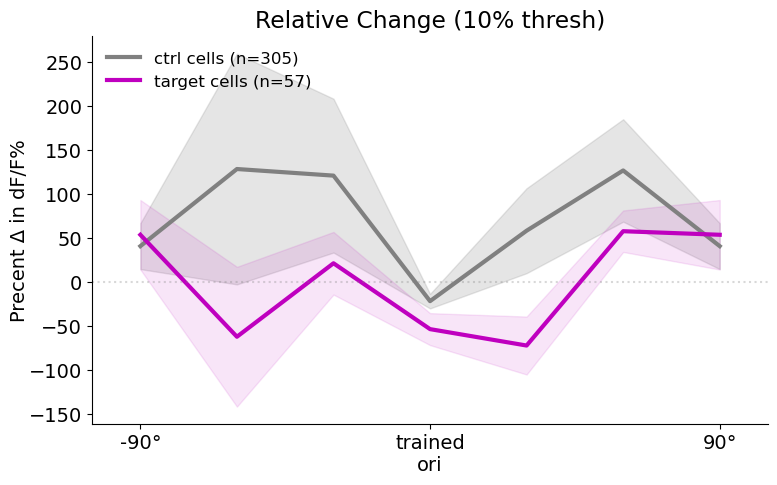

In [71]:
# Plotting Comparing Average Response of Cells with Relative (percent change) to Absolute Change
fig, axis = plt.subplots(1, 1, figsize=(8,5))

avg_ctrl = np.nanmean(relative_dfof_ctrl, axis=0)
avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
sem_ctrl = stats.sem(relative_dfof_ctrl, axis=(0),nan_policy='omit')
sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))

avg_bhStim = np.nanmean(relative_dfof, axis=0)
avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))
sem_bhStim = stats.sem(relative_dfof, axis=(0),nan_policy='omit')
sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))

axis.set_title("Relative Change (%i%% thresh)" % quiet_cell_threshold)

difs = [avg_ctrl, avg_bhStim]

colors = ['grey', 'm']
font = {'size'   : 14}
mpl.rc('font', **font)
xs = [0,1,2,3,4,5,6]

axis.plot(difs[0],color=colors[0],lw=3,label='ctrl cells (n=%i)' %relative_dfof_ctrl.shape[0])
axis.plot(difs[1],color=colors[1],lw=3,label='target cells (n=%i)' %relative_dfof.shape[0])
axis.fill_between(xs,difs[0]+sem_ctrl,difs[0]-sem_ctrl,color=colors[0],alpha=0.2)
axis.fill_between(xs,difs[1]+sem_bhStim,difs[1]-sem_bhStim,color=colors[1],alpha=0.1)
axis.set_xticks(
    ticks=[0, 3, 6],
    labels=["-90\u00b0", "trained\nori", "90\u00b0"])
axis.set_ylabel('Precent Δ in dF/F%',labelpad= 0)
axis.set_xlim([-0.5,6.5])
#axis.set_ylim([-500,2000])

# # Plotting statistical significance
# data = np.concatenate((avg_bhStim, avg_ctrl)).flatten() # flattening plotted data to find max 
# y_position = data.max() * 1.2 # creating location for asterisks
# for idx, pval in enumerate(asterisks):
#     plt.text(x=idx, y=y_position, s=pval)

# Plot scatter of y-vlaues on -90 deg 
x_scatter = [0] * relative_dfof[:,0].shape[0]
x_scatter_ = [3] * relative_dfof[:,0].shape[0]

# axis.scatter(x_scatter,relative_dfof[:,0],s=5)
# axis.scatter(x_scatter_,relative_dfof[:,3], s=5)

axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.axhline(c='grey',alpha=0.3,ls=':'); 
#axis.axvline(x=3,c=colors[1],alpha=0.5, ls='--',lw=4, label='target ori')
axis.legend(loc='upper left',fontsize=12,frameon=False)
    
plt.subplots_adjust(wspace=None, hspace=None); plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

#plt.savefig(file_path_save+'changeplot_wsem.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/friedmanng/Desktop/umd_nih/2024commeetee/changeplot_sup.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/phillipscm/Downloads/241021-figs/changeplot_tuncurve.png',bbox_inches='tight',dpi=400)

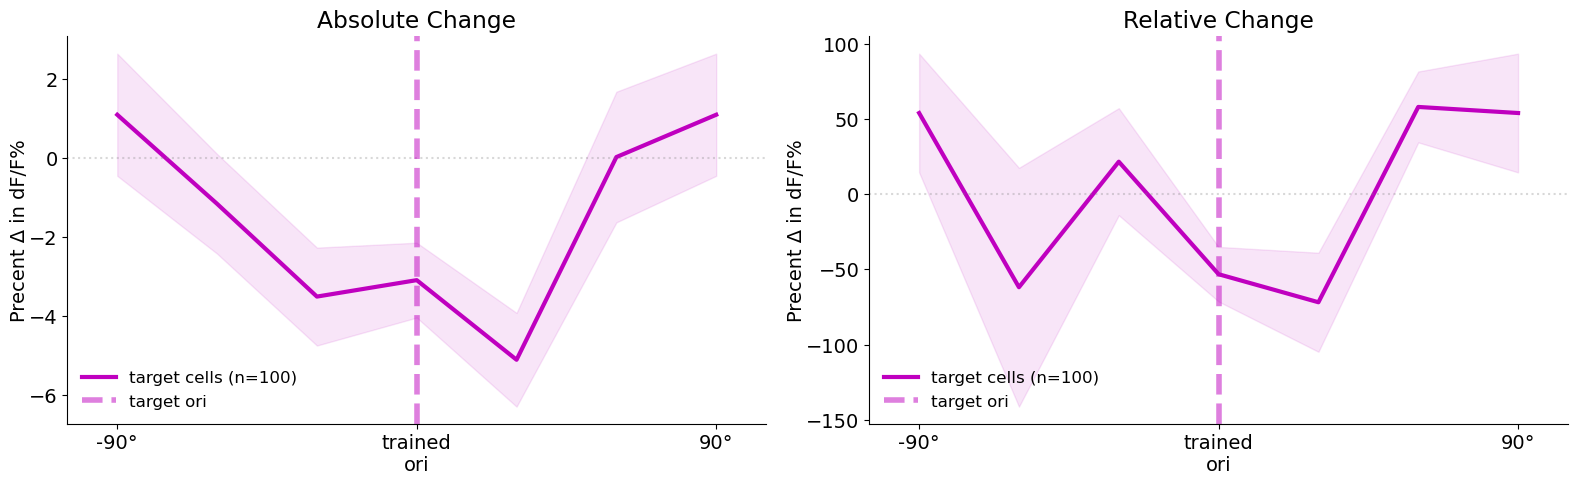

In [70]:
# Plotting Comparing Average Response of Cells with Relative (percent change) to Absolute Change
fig, axes = plt.subplots(1, 2, figsize=(16,5))
data_storage = [dfoF_V_change_ctrl,dfoF_V_change_bhStim]

for i, axis in enumerate(axes): 

    if i == 0:
        avg_ctrl = np.nanmean(dfoF_V_change_ctrl, axis=0)
        avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
        sem_ctrl = stats.sem(dfoF_V_change_ctrl, axis=(0),nan_policy='omit')
        sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))
    
        avg_bhStim = np.nanmean(dfoF_V_change_bhStim[~trained_stay_quiet_cells], axis=0)
        avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))
        sem_bhStim = stats.sem(dfoF_V_change_bhStim[~trained_stay_quiet_cells], axis=(0),nan_policy='omit')
        sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))
        
        axis.set_title("Absolute Change")

    else:
        avg_bhStim = np.nanmean(relative_dfof, axis=0)
        avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))
        sem_bhStim = stats.sem(relative_dfof, axis=(0),nan_policy='omit')
        sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))
        
        axis.set_title("Relative Change")

    difs = [avg_ctrl, avg_bhStim]

    colors = ['grey', 'm']
    font = {'size'   : 14}
    mpl.rc('font', **font)
    xs = [0,1,2,3,4,5,6]

  #  axis.plot(difs[0],color=colors[0],lw=3,label='ctrl cells (n=%i)' %dfoF_V_change_ctrl.shape[0])
    axis.plot(difs[1],color=colors[1],lw=3,label='target cells (n=%i)' %dfoF_V_change_bhStim.shape[0])
#    axis.fill_between(xs,difs[0]+sem_ctrl,difs[0]-sem_ctrl,color=colors[0],alpha=0.2)
    axis.fill_between(xs,difs[1]+sem_bhStim,difs[1]-sem_bhStim,color=colors[1],alpha=0.1)
    axis.set_xticks(
        ticks=[0, 3, 6],
        labels=["-90\u00b0", "trained\nori", "90\u00b0"])
    axis.set_ylabel('Precent Δ in dF/F%',labelpad= 0)
#    axis.set_ylim([-7,6.5])
    axis.set_xlim([-0.5,6.5])
            
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.axhline(c='grey',alpha=0.3,ls=':'); axis.axvline(x=3,c=colors[1],alpha=0.5, ls='--',lw=4, label='target ori')
    axis.legend(loc='lower left',fontsize=12,frameon=False)
    
plt.subplots_adjust(wspace=None, hspace=None); plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

#plt.savefig(file_path_save+'changeplot_wsem.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/friedmanng/Desktop/umd_nih/2024commeetee/changeplot_sup.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/phillipscm/Downloads/241021-figs/changeplot_tuncurve.png',bbox_inches='tight',dpi=400)

### Aligned by Preferred Orientation (old)

In [48]:
# Finding the orientation with the highest response for each cell (preferred tuning)
maxes = np.max(visResp_behavStim_pre,axis=1)
max_locs = np.argmax(visResp_behavStim_pre,axis=1)

# Pulling the cell index of the maximum value for each orientation (associates cells with their preferred ori)
preferred_ori_inds = [np.where(max_locs == ori_dir) for ori_dir in range(6)]

# Pulling the maximum values in the same way
max_cells = [maxes[preferred_ori_inds[ori_dir]] for ori_dir in range(6)]

# Create a dictionary for easy query
oris = [0, 30, 60, 90, 120, 150]
ori_dict = dict(zip(oris,preferred_ori_inds))

In [49]:
# Repeating the above but for the control cells 
# Finding the orientation with the highest response for each cell (preferred tuning)
maxes = np.max(ctrl_vis_pre,axis=1)
max_locs = np.argmax(ctrl_vis_pre,axis=1)

# Pulling the cell index of the maximum value for each orientation (associates cells with their preferred ori)
preferred_ori_inds = [np.where(max_locs == ori_dir) for ori_dir in range(6)]

# Pulling the maximum values in the same way
max_cells = [maxes[preferred_ori_inds[ori_dir]] for ori_dir in range(6)]

# Create a dictionary for easy query
oris = [0, 30, 60, 90, 120, 150]
ori_dict_ctrl = dict(zip(oris,preferred_ori_inds))

In [50]:
# Hand calculated index change arrays for each ori, this is the change in index locations for orientation
# a janky way to do this plot but...
index_shift_array = [[3,4,5,0,1,2],[2,3,4,5,0,1],[1,2,3,4,5,0],[0,1,2,3,4,5],[5,0,1,2,3,4],[4,5,0,1,2,3]]
#index_shift_array = [[3,3,3,-3,-3,-3],[2,2,2,2,-4,-4],[1,1,1,1,1,-5],[0,0,0,0,0,0],[5,-1,-1,-1,-1,-1],[4,4,-2,-2,-2,-2]]

shift_dict = dict(zip(oris,index_shift_array))

In [51]:
# Aligns data based on preferred orientation preference 
start_inds = [0, 1, 2, 3, 4, 5]
datas = [dfoF_V_change_bhStim,dfoF_V_change_ctrl]
dicts = [ori_dict,ori_dict_ctrl]
stim_ori_aligned = np.zeros(dfoF_V_change_bhStim.shape)
ctrl_ori_aligned = np.zeros(dfoF_V_change_ctrl.shape)

for i,dataset in enumerate(datas): 
    row_num = 0 
    group_dict = dicts[i] # trained and control cells
    
    # Loop over each orientation
    for ori, ori_org_cell_inds in group_dict.items():

        # Create a list of indices to shift values such that the preferred orientation is in the 3 index
        # Uses above hand-coded arrays, the purpose of this is to plot relative to a cells preferred tuning
        reorder = shift_dict[ori]

        # Pulls data from each cell of a given orientation
        # Need [0] to pull array out of tuple
        for cell_ind in ori_org_cell_inds[0]:
            data = dataset[cell_ind,:]

            # Reorder data from each cell such that the preferred orientation is in index 3
            holder = [0] * len(data) 
            for ind in range(len(data)):
                holder[reorder[ind]] = data[ind]

            # Store data in new matrix
            if dataset.shape == dfoF_V_change_bhStim.shape:
                stim_ori_aligned[row_num,:] = holder
            else:
                ctrl_ori_aligned[row_num,:] = holder

            row_num = row_num + 1
            

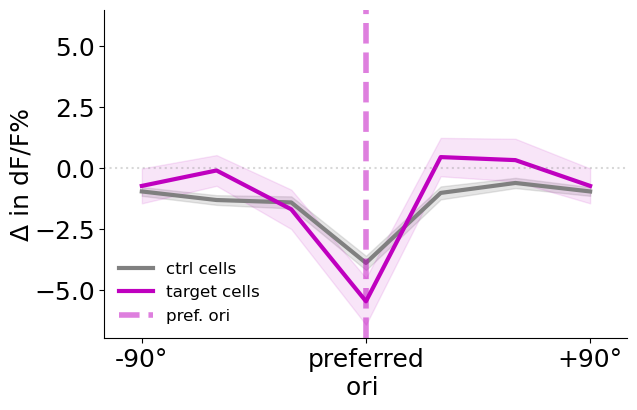

In [52]:
# Plotting data aligned by preferred orientation
avg_ctrl = np.nanmean(ctrl_ori_aligned, axis=0)
avg_ctrl = np.concatenate((avg_ctrl, avg_ctrl[:1]))
avg_bhStim = np.nanmean(stim_ori_aligned, axis=0)
avg_bhStim = np.concatenate((avg_bhStim, avg_bhStim[:1]))

sem_ctrl = stats.sem(ctrl_ori_aligned, axis=(0),nan_policy='omit')
sem_ctrl = np.concatenate((sem_ctrl, sem_ctrl[:1]))
sem_bhStim = stats.sem(stim_ori_aligned, axis=(0),nan_policy='omit')
sem_bhStim = np.concatenate((sem_bhStim, sem_bhStim[:1]))

difs = [avg_ctrl, avg_bhStim]

fig= plt.figure(figsize=(12,8))
#fig.text(0.5, 0.435, '*sub selected visually responsive (df/f>7)\nnot stimd cell pop to match mean vis resp of stimd cells', ha='left', va='center', fontsize=10)
colors = ['grey', 'm']
font = {'size'   : 18}
mpl.rc('font', **font)
#fig.text(0.52, 0.44, 'orientation', ha='center', va='center')
xs = [0,1,2,3,4,5,6]

ax1 = fig.add_subplot(221)
ax1.plot(difs[0],color=colors[0],lw=3,label='ctrl cells')
ax1.plot(difs[1],color=colors[1],lw=3,label='target cells')
ax1.fill_between(xs,difs[0]+sem_ctrl,difs[0]-sem_ctrl,color=colors[0],alpha=0.2)
ax1.fill_between(xs,difs[1]+sem_bhStim,difs[1]-sem_bhStim,color=colors[1],alpha=0.1)
#ax1.set_xlabel('orientation')
ax1.set_xticks([0,3,6]); ax1.set_xticklabels(['-90°','preferred\nori ','+90°'])
ax1.set_ylabel('Δ in dF/F%',labelpad= 0)
ax1.set_ylim([-7,6.5])
ax1.set_xlim([-0.5,6.5])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axhline(c='grey',alpha=0.3,ls=':'); ax1.axvline(x=3,c=colors[1],alpha=0.5, ls='--',lw=4, label='pref. ori')
ax1.legend(loc='lower left',fontsize=12,frameon=False)
plt.subplots_adjust(wspace=None, hspace=None); plt.tight_layout()
#plt.savefig(file_path_save+'changeplot_wsem.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/friedmanng/Desktop/umd_nih/2024commeetee/changeplot_sup.png',bbox_inches='tight',dpi=400)
#plt.savefig('/Users/phillipscm/Downloads/241021-figs/changeplot_tuncurve.png',bbox_inches='tight',dpi=400)
ax1.title("M